In [1]:
"""
- All critical fixes and best practices from literature

References:
-----------
- Piironen & Vehtari (2017): "Sparsity information and regularization in the horseshoe"
- Clifford et al. (2012): "Signal quality indices and data fusion"
- Gelman et al. (2020): "Regression and Other Stories"
- Vehtari et al. (2021): "Rank-Normalization, Folding, and Localization"
- Betancourt (2017): "A Conceptual Introduction to Hamiltonian Monte Carlo"

Author: Final Hybrid Implementation
Date: January 30, 2026
Status: Production Ready 
"""

import os
import warnings
import logging
from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Tuple, Dict, List

# Core computation
import numpy as np
import pandas as pd
from scipy.signal import welch, butter, filtfilt
from scipy.stats import skew, kurtosis

# ECG processing
import wfdb

# Bayesian modeling
import pymc as pm
import arviz as az

# Machine learning utilities
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    brier_score_loss, log_loss,
    roc_curve, precision_recall_curve,
    confusion_matrix
)

# Parallel processing
from joblib import Parallel, delayed
from tqdm.auto import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Environment configuration
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["OPENBLAS_NUM_THREADS"] = "8"
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


# Configuration

In [2]:
@dataclass(frozen=True)
class Config:
    """Pipeline configuration with validated defaults based on literature."""
    
    # Data paths
    data_root: Path
    cache_dir: Path
    
    # Processing parameters
    max_records: Optional[int] = None
    n_jobs: int = 8
    leads: Tuple[int, ...] = tuple(range(12))
    
    # Signal processing (Clifford et al. 2012)
    bp_low: float = 0.5        # Remove baseline wander
    bp_high: float = 40.0      # Preserve QRS complex
    bp_order: int = 3          # Butterworth filter order
    
    # Feature selection
    variance_threshold: float = 0.001
    n_features_to_select: int = 25
    
    # Bayesian sampling (conservative settings for convergence)
    n_draws: int = 2000
    n_tune: int = 3000        
    n_chains: int = 4
    target_accept: float = 0.95
    max_treedepth: int = 12
    
    # Cross-validation
    n_cv_folds: int = 5
    
    # Model specification
    expected_sparsity: float = 0.3  # Prior belief about relevant features
    random_seed: int = 42
    
    @property
    def db_csv(self) -> Path:
        return self.data_root / "ptbxl_database.csv"
    
    @property
    def features_csv(self) -> Path:
        return self.cache_dir / "features_final_hybrid.csv"
    
    @property
    def results_dir(self) -> Path:
        return self.cache_dir / "results_final"
    
    def __post_init__(self):
        """Ensure output directories exist."""
        object.__setattr__(self, 'cache_dir', Path(self.cache_dir))
        object.__setattr__(self, 'data_root', Path(self.data_root))
        self.cache_dir.mkdir(parents=True, exist_ok=True)
        self.results_dir.mkdir(parents=True, exist_ok=True)


# Label construction

In [3]:
def create_degradation_labels(db: pd.DataFrame) -> np.ndarray:
    """
    Create binary quality labels from PTB-XL noise annotations.
    
    A record is labeled as degraded (1) if it has ANY noise annotation.
    This follows a conservative approach appropriate for clinical QA.
    """
    noise_cols = [
        "baseline_drift",
        "static_noise", 
        "burst_noise",
        "electrodes_problems"
    ]
    
    def to_flag(x):
        """Convert annotation to binary flag."""
        if pd.isna(x):
            return 0
        s = str(x).strip()
        if s == "" or s.lower() == "nan":
            return 0
        try:
            return int(float(s) != 0.0)
        except:
            return 1
    
    flags = db[noise_cols].map(to_flag)
    labels = (flags.sum(axis=1) > 0).astype(int).to_numpy()
    
    logger.info(f"Label distribution: Clean={np.sum(labels==0)} ({100*np.mean(labels==0):.1f}%), "
                f"Degraded={np.sum(labels==1)} ({100*np.mean(labels==1):.1f}%)")
    
    return labels

# Signal processing 

In [4]:
def _bandpass_filter(
    x: np.ndarray, 
    fs: float, 
    low: float, 
    high: float, 
    order: int = 3
) -> np.ndarray:
    """
    Apply Butterworth bandpass filter with robust parameter validation.
    
    Based on: Clifford et al. (2012) - Signal quality indices
    """
    if x.size < 64 or fs <= 0:
        return x
    
    nyq = 0.5 * fs
    lo = max(low / nyq, 1e-6)
    hi = min(high / nyq, 0.999999)
    
    if not (0 < lo < hi < 1):
        return x
    
    try:
        b, a = butter(order, [lo, hi], btype="bandpass")
        padlen = min(3 * max(len(a), len(b)), x.size - 1)
        
        if padlen < 1:
            return x
            
        return filtfilt(b, a, x, padlen=padlen)
    except Exception as e:
        logger.debug(f"Filtering failed: {e}")
        return x


def _welch_psd(
    x: np.ndarray, 
    fs: float, 
    nperseg: int = 1024
) -> Tuple[Optional[np.ndarray], Optional[np.ndarray]]:
    """
    Compute power spectral density using Welch's method.
    
    Returns:
    --------
    f : array or None - Frequency bins
    pxx : array or None - Power spectral density
    """
    x = x[np.isfinite(x)]
    
    if x.size < 16:
        return None, None
    
    nperseg = min(nperseg, x.size)
    if nperseg < 16:
        return None, None
    
    try:
        f, pxx = welch(x, fs=fs, nperseg=nperseg, scaling="density")
        return f, pxx
    except Exception as e:
        logger.debug(f"PSD computation failed: {e}")
        return None, None


def _bandpower(
    f: Optional[np.ndarray], 
    pxx: Optional[np.ndarray], 
    low: float, 
    high: float
) -> float:
    """Integrate PSD over specified frequency band."""
    if f is None or pxx is None:
        return 0.0
    
    mask = (f >= low) & (f < high)
    if not np.any(mask):
        return 0.0
    
    return float(np.trapezoid(pxx[mask], f[mask]))


# Feature extraction

In [5]:
def compute_sqi_features(
    x: np.ndarray, 
    fs: float, 
    cfg: Config
) -> Dict[str, float]:
    """
    Extract comprehensive signal quality indices from a single ECG lead.
    
    Features include:
    - Statistical moments (mean, std, skewness, kurtosis)
    - Spectral power in clinical bands
    - Signal quality indices (pSQI, basSQI)
    - Hjorth parameters (mobility, complexity)
    
    Based on: Li et al. (2016), Clifford et al. (2012)
    """
    x = x[np.isfinite(x)]
    
    # Initialize feature dictionary
    features = {
        # Statistical
        "mean": 0.0, "std": 0.0, "skew": 0.0, "kurt": 0.0,
        "rms": 0.0, "ptp": 0.0,
        
        # Spectral power
        "p_baseline": 0.0,    # 0-1 Hz
        "p_qrs": 0.0,         # 5-40 Hz
        "p_high_freq": 0.0,   # 40-100 Hz
        "p_total": 0.0,
        
        # Quality indices
        "pSQI": 0.0,
        "basSQI": 0.0,
        
        # Hjorth parameters
        "mobility": 0.0,
        "complexity": 0.0,
        
        # Spectral fractions
        "frac_baseline": 0.0,
        "frac_qrs": 0.0,
        "frac_high": 0.0
    }
    
    if x.size < 64:
        return features
    
    # Apply bandpass filter
    x_filt = _bandpass_filter(x, fs, cfg.bp_low, cfg.bp_high, cfg.bp_order)
    
    # Statistical features
    features["mean"] = float(np.mean(x_filt))
    features["std"] = float(np.std(x_filt))
    features["rms"] = float(np.sqrt(np.mean(x_filt**2)))
    features["ptp"] = float(np.ptp(x_filt))
    
    if x_filt.size >= 8:
        features["skew"] = float(skew(x_filt))
        features["kurt"] = float(kurtosis(x_filt))
    
    # Hjorth parameters
    diff1 = np.diff(x_filt)
    diff2 = np.diff(diff1)
    
    var_x = np.var(x_filt)
    var_d1 = np.var(diff1)
    var_d2 = np.var(diff2)
    
    if var_x > 1e-12:
        features["mobility"] = float(np.sqrt(var_d1 / var_x))
        
        if var_d1 > 1e-12:
            complexity = np.sqrt(var_d2 / var_d1) / features["mobility"]
            features["complexity"] = float(complexity)
    
    # Spectral features
    f, pxx = _welch_psd(x_filt, fs)
    
    if f is not None:
        # Power in clinical frequency bands
        p_0_1 = _bandpower(f, pxx, 0.0, 1.0)
        p_0_40 = _bandpower(f, pxx, 0.0, 40.0)
        p_5_40 = _bandpower(f, pxx, 5.0, 40.0)
        p_40_100 = _bandpower(f, pxx, 40.0, min(100.0, fs/2))
        p_tot = _bandpower(f, pxx, 0.0, fs/2)
        
        features["p_baseline"] = p_0_1
        features["p_qrs"] = p_5_40
        features["p_high_freq"] = p_40_100
        features["p_total"] = p_tot
        
        # Signal quality indices
        if p_0_40 > 1e-12:
            features["pSQI"] = p_5_40 / p_0_40
            features["basSQI"] = 1.0 - (p_0_1 / p_0_40)
        
        # Spectral fractions
        if p_tot > 1e-12:
            features["frac_baseline"] = p_0_1 / p_tot
            features["frac_qrs"] = p_5_40 / p_tot
            features["frac_high"] = p_40_100 / p_tot
        
        # Clip quality indices to valid ranges
        features["basSQI"] = float(np.clip(features["basSQI"], -1, 1))
        features["pSQI"] = float(np.clip(features["pSQI"], 0, 2))
    
    return features


def aggregate_lead_features(per_lead: List[Dict[str, float]]) -> Dict[str, float]:
    """
    Aggregate features across leads using robust statistics.
    
    For each feature, compute mean, min, max, and std.
    """
    if not per_lead:
        return {}
    
    keys = sorted(per_lead[0].keys())
    mat = np.array([[d[k] for k in keys] for d in per_lead])
    
    agg = {}
    for j, k in enumerate(keys):
        col = mat[:, j]
        agg[f"{k}_mean"] = float(np.mean(col))
        agg[f"{k}_min"] = float(np.min(col))
        agg[f"{k}_max"] = float(np.max(col))
        agg[f"{k}_std"] = float(np.std(col))
    
    return agg

# Record processing 

In [6]:
def resolve_record_path(data_root: Path, filename: str) -> Optional[Path]:
    """Find .hea file for PTB-XL record in standard directory structure."""
    rel = str(filename).replace("\\", "/").split(".")[0]
    
    candidates = [
        data_root / rel,
        data_root / "records500" / rel,
        data_root / "records100" / rel
    ]
    
    for base in candidates:
        if base.with_suffix(".hea").exists():
            return base
    
    return None


def process_record(
    idx: int, 
    db_row: pd.Series, 
    y_val: int, 
    cfg: Config
) -> Tuple[Optional[Dict], Optional[str]]:
    """
    Extract features from a single ECG record with robust error handling.
    """
    base = resolve_record_path(cfg.data_root, db_row["filename_hr"])
    if base is None:
        return None, "missing_file"
    
    try:
        # Load signal
        sig, fields = wfdb.rdsamp(str(base))
        fs = float(fields.get("fs", 500.0))
        
        # Validate signal shape
        if sig.ndim != 2:
            return None, f"bad_shape_ndim={sig.ndim}"
        
        if sig.shape[1] < 12:
            return None, f"insufficient_leads={sig.shape[1]}"
        
        # Select leads
        n_leads = sig.shape[1]
        use_leads = [l for l in cfg.leads if l < n_leads] or [0]
        
        # Extract features per lead
        per_lead = [
            compute_sqi_features(sig[:, l], fs, cfg) 
            for l in use_leads
        ]
        
        # Aggregate across leads
        features = aggregate_lead_features(per_lead)
        
        # Create output row
        row = {
            "ecg_id": db_row["ecg_id"], 
            "y": int(y_val), 
            "fs": fs
        }
        row.update(features)
        
        return row, None
        
    except Exception as e:
        return None, str(e)


def extract_features(
    db: pd.DataFrame, 
    y: np.ndarray, 
    cfg: Config
) -> pd.DataFrame:
    """Extract SQI features from all records in parallel."""
    n_use = len(db) if cfg.max_records is None else min(cfg.max_records, len(db))
    db_sub = db.iloc[:n_use].reset_index(drop=True)
    y_sub = y[:n_use]
    
    logger.info(f"Extracting features from {n_use} records using {cfg.n_jobs} cores...")
    
    results = Parallel(n_jobs=cfg.n_jobs, backend="loky")(
        delayed(process_record)(i, db_sub.iloc[i], y_sub[i], cfg)
        for i in tqdm(range(n_use), desc="Processing records")
    )
    
    # Separate successful and failed records
    rows = []
    errors = []
    
    for row, err in results:
        if row is not None:
            rows.append(row)
        if err is not None:
            errors.append(err)
    
    if not rows:
        raise RuntimeError("No features extracted successfully")
    
    # Create DataFrame and handle invalid values
    feat_df = (
        pd.DataFrame(rows)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )
    
    logger.info(f"Successfully processed: {len(rows)}/{n_use} records")
    if errors:
        logger.warning(f"Failed records: {len(errors)}")
    
    return feat_df


def load_or_cache_features(
    db: pd.DataFrame, 
    y: np.ndarray, 
    cfg: Config,
    use_cache: bool = True
) -> pd.DataFrame:
    """Load cached features or extract new ones."""
    if use_cache and cfg.features_csv.exists():
        feat_df = pd.read_csv(cfg.features_csv)
        
        n_expected = len(db) if cfg.max_records is None else min(cfg.max_records, len(db))
        
        if len(feat_df) == n_expected and "y" in feat_df.columns:
            logger.info(f"Loaded cached features from {cfg.features_csv}")
            return feat_df
    
    # Extract features
    feat_df = extract_features(db, y, cfg)
    
    # Cache results
    feat_df.to_csv(cfg.features_csv, index=False)
    logger.info(f"Saved features to {cfg.features_csv}")
    
    return feat_df



# Feature

In [7]:
class FeatureSelector:
    """
    
    Steps:
    1. Remove low-variance features
    2. Select top-k by mutual information
    3. Apply robust scaling (median/IQR)
    """
    
    def __init__(self, n_features: int = 25, variance_threshold: float = 0.001, random_state: int = 42):
        self.n_features = n_features
        self.random_state = random_state
        self.variance_selector = VarianceThreshold(threshold=variance_threshold)
        
        # State variables
        self.selected_indices = None  # Indices in variance-filtered space
        self.selected_features = None  # Feature names for interpretability
        self.scaler_median = None
        self.scaler_iqr = None
    
    def fit_transform(
        self, 
        X: np.ndarray, 
        y: np.ndarray, 
        feature_names: List[str]
    ) -> np.ndarray:
        """
        Select features and transform data.
        
        Returns:
        --------
        X_scaled : Scaled selected features
        """
        logger.info(f"Feature selection: {X.shape[1]} features → {self.n_features}")
        
        # Step 1: Variance filter
        X_var = self.variance_selector.fit_transform(X)
        var_mask = self.variance_selector.get_support()
        
        cols_after_var = [feature_names[i] for i in range(len(feature_names)) if var_mask[i]]
        logger.info(f"  After variance filter: {X_var.shape[1]} features")
        
        # Step 2: Mutual information selection
        if X_var.shape[1] > self.n_features:
            mi_scores = mutual_info_classif(
                X_var, y, 
                discrete_features=False,
                random_state=self.random_state
            )
            
            # Select top-k indices (relative to X_var)
            self.selected_indices = np.argsort(mi_scores)[-self.n_features:]
            X_selected = X_var[:, self.selected_indices]
            
            self.selected_features = [cols_after_var[i] for i in self.selected_indices]
            logger.info(f"  After MI selection: {self.n_features} features")
        else:
            self.selected_indices = np.arange(X_var.shape[1])
            X_selected = X_var
            self.selected_features = cols_after_var
            logger.info(f"  Using all {X_var.shape[1]} features (< n_features)")
        
        # Step 3: Robust scaling
        self.scaler_median = np.median(X_selected, axis=0)
        self.scaler_iqr = (
            np.percentile(X_selected, 75, axis=0) - 
            np.percentile(X_selected, 25, axis=0) + 
            1e-8
        )
        
        X_scaled = (X_selected - self.scaler_median) / self.scaler_iqr
        
        return X_scaled
    
    def transform(self, X: np.ndarray) -> np.ndarray:
        """
        Transform new data using fitted selectors.
        
        FIXED: Correctly applies variance filter before column selection.
        """
        if self.selected_indices is None:
            raise ValueError("FeatureSelector not fitted. Call fit_transform() first.")
        
        # Step 1: Apply variance filter (using fitted support)
        X_var = self.variance_selector.transform(X)
        
        # Step 2: Apply column selection (indices are relative to X_var)
        X_selected = X_var[:, self.selected_indices]
        
        # Step 3: Apply scaling
        X_scaled = (X_selected - self.scaler_median) / self.scaler_iqr
        
        return X_scaled



# Model A- Bayesian LR

In [8]:
class BayesianECGClassifier:
    """
    Regularized Bayesian logistic regression with horseshoe prior.
    
    Implements the model from Piironen & Vehtari (2017) with:
    - Regularized horseshoe prior for sparse coefficients
    - Class-balanced weighting for imbalanced data
    - Comprehensive MCMC diagnostics
    """
    
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.feature_selector = FeatureSelector(
            n_features=cfg.n_features_to_select,
            variance_threshold=cfg.variance_threshold,
            random_state=cfg.random_seed
        )
        
        self.trace = None
        self.model = None
    
    def _compute_class_weights(self, y: np.ndarray) -> np.ndarray:
        """Compute balanced class weights for imbalanced data."""
        class_counts = np.bincount(y)
        weights = len(y) / (2.0 * class_counts)
        return weights[y]
    
    def fit(
        self, 
        X: np.ndarray, 
        y: np.ndarray, 
        feature_names: List[str]
    ):
        """
        Fit Bayesian logistic regression model.
        """
        logger.info("Fitting Bayesian logistic regression...")
        
        # Feature selection (internal to prevent leakage)
        X_scaled = self.feature_selector.fit_transform(X, y, feature_names)
        
        # Class weights for imbalanced data
        weights = self._compute_class_weights(y)
        
        N, D = X_scaled.shape
        logger.info(f"Model dimensions: N={N}, D={D}, Expected sparsity={self.cfg.expected_sparsity}")
        
        # Build PyMC model
        with pm.Model() as self.model:
            # Intercept prior
            alpha = pm.Normal("alpha", mu=0.0, sigma=2.5)
            
            # Regularized horseshoe prior
            p0 = max(3, int(D * self.cfg.expected_sparsity))
            tau0 = (p0 / (D - p0)) * (1.0 / np.sqrt(N))
            
            # Global shrinkage
            tau = pm.HalfCauchy("tau_global", beta=tau0)
            
            # Slab scale
            c2 = pm.InverseGamma("c2_slab", alpha=2.0, beta=2.0)
            
            # Local shrinkage
            lambda_local = pm.HalfCauchy("lambda_local", beta=1.0, shape=D)
            
            # Regularized local scale
            lambda_tilde = pm.math.sqrt(c2) * lambda_local / pm.math.sqrt(
                c2 + tau**2 * lambda_local**2
            )
            
            # Non-centered parameterization
            beta_raw = pm.Normal("beta_raw", mu=0.0, sigma=1.0, shape=D)
            beta = pm.Deterministic("beta", tau * lambda_tilde * beta_raw)
            
            # Linear predictor
            eta = alpha + pm.math.dot(X_scaled, beta)
            
            # Weighted likelihood
            pm.Potential(
                "weighted_likelihood",
                weights * pm.logp(pm.Bernoulli.dist(logit_p=eta), y)
            )
        
        # Sample from posterior
        logger.info(f"Sampling: {self.cfg.n_draws} draws × {self.cfg.n_chains} chains "
                   f"(tune={self.cfg.n_tune}, target_accept={self.cfg.target_accept})")
        
        with self.model:
            self.trace = pm.sample(
                draws=self.cfg.n_draws,
                tune=self.cfg.n_tune,
                chains=self.cfg.n_chains,
                target_accept=self.cfg.target_accept,
                random_seed=self.cfg.random_seed,
                init="adapt_diag",
                nuts_sampler="numpyro",
                idata_kwargs={"log_likelihood": False},
                return_inferencedata=True
            )
        
        # Check diagnostics
        self._check_convergence()
        
        logger.info("Sampling complete")
        
        return self
    
    def _check_convergence(self):
        """Check MCMC convergence and log warnings if issues detected."""
        divergent = np.asarray(self.trace.sample_stats.diverging)
        n_divergent = int(divergent.sum())
        total_samples = divergent.size
        
        summary = az.summary(
            self.trace, 
            var_names=["beta", "alpha", "tau_global"],
            hdi_prob=0.95
        )
        
        rhat_vals = summary["r_hat"].dropna().values
        n_bad_rhat = int((rhat_vals > 1.01).sum())
        
        ess_bulk = summary["ess_bulk"].dropna().values
        min_ess_bulk = np.nanmin(ess_bulk)
        
        logger.info(f"Convergence checks:")
        logger.info(f"  Divergences: {n_divergent}/{total_samples} ({100*n_divergent/total_samples:.2f}%)")
        logger.info(f"  Parameters with R-hat > 1.01: {n_bad_rhat}/{len(rhat_vals)}")
        logger.info(f"  Min ESS (bulk): {min_ess_bulk:.0f}")
        
        if n_divergent > 0:
            logger.warning("⚠️  Divergences detected! Consider increasing target_accept or reparameterizing.")
        
        if n_bad_rhat > 0:
            logger.warning("⚠️  High R-hat values detected! Consider more draws or checking model.")
        
        if min_ess_bulk < 400:
            logger.warning("⚠️  Low ESS detected! Consider more iterations.")
    
    def predict_proba(self, X: np.ndarray) -> Dict[str, np.ndarray]:
        """
        Compute posterior predictive probabilities.
        
        Returns:
        --------
        dict with keys:
            'mean' : Posterior mean probability
            'std' : Posterior standard deviation
            'lower' : 2.5th percentile (95% CI)
            'upper' : 97.5th percentile (95% CI)
        """
        if self.trace is None:
            raise ValueError("Model not fitted. Call fit() first.")
        
        # Transform features using fitted selector
        X_scaled = self.feature_selector.transform(X)
        
        # Extract posterior samples
        beta_samples = self.trace.posterior["beta"].values
        alpha_samples = self.trace.posterior["alpha"].values
        
        # Reshape for matrix operations
        beta_flat = beta_samples.reshape(-1, beta_samples.shape[-1])
        alpha_flat = alpha_samples.flatten()
        
        # Compute logits for each posterior sample
        eta = alpha_flat[:, None] + beta_flat @ X_scaled.T
        
        # Convert to probabilities
        p_samples = 1.0 / (1.0 + np.exp(-np.clip(eta, -20, 20)))
        
        # Compute summaries
        return {
            'mean': np.mean(p_samples, axis=0),
            'std': np.std(p_samples, axis=0),
            'lower': np.percentile(p_samples, 2.5, axis=0),
            'upper': np.percentile(p_samples, 97.5, axis=0)
        }
    
    def get_feature_importance(self) -> pd.DataFrame:
        """Extract feature importance from posterior distributions."""
        summary = az.summary(
            self.trace, 
            var_names=["beta"],
            hdi_prob=0.95
        )
        
        summary["feature"] = self.feature_selector.selected_features
        summary["abs_mean"] = summary["mean"].abs()
        
        return summary.set_index("feature").sort_values("abs_mean", ascending=False)


# Posterior pred and evals 

In [9]:
# ============================================================================
# 8. EVALUATION METRICS
# ============================================================================

def evaluate_predictions(
    y_true: np.ndarray,
    predictions: Dict[str, np.ndarray]
) -> Dict[str, float]:
    """Comprehensive evaluation metrics for probabilistic predictions."""
    p_mean = predictions['mean']
    p_lower = predictions['lower']
    p_upper = predictions['upper']
    
    y_pred = (p_mean >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    metrics = {
        'roc_auc': roc_auc_score(y_true, p_mean),
        'auprc': average_precision_score(y_true, p_mean),
        'brier_score': brier_score_loss(y_true, p_mean),
        'log_loss': log_loss(y_true, p_mean),
        'ci_coverage': np.mean((y_true >= p_lower) & (y_true <= p_upper)),
        'sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        'ppv': tp / (tp + fp) if (tp + fp) > 0 else 0.0,
        'npv': tn / (tn + fn) if (tn + fn) > 0 else 0.0,
    }
    
    return metrics



# Visualization

In [12]:
def plot_comparison_dashboard(
    val_metrics: Dict[str, float],
    test_metrics: Dict[str, float],
    test_predictions: Dict[str, np.ndarray],
    y_test: np.ndarray,
    importance: pd.DataFrame,
    save_path: Path
):
    """Generate comprehensive comparison dashboard."""
    fig = plt.figure(figsize=(20, 12))
    sns.set_style("whitegrid")
    
    p_mean = test_predictions['mean']
    p_lower = test_predictions['lower']
    p_upper = test_predictions['upper']
    
    # 1. ROC Curve
    ax1 = plt.subplot(3, 3, 1)
    fpr, tpr, _ = roc_curve(y_test, p_mean)
    ax1.plot(fpr, tpr, 'b-', lw=2, label=f"Test AUC = {test_metrics['roc_auc']:.4f}")
    ax1.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3)
    ax1.set_xlabel("False Positive Rate")
    ax1.set_ylabel("True Positive Rate")
    ax1.set_title("ROC Curve (Bayesian LR)")
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # 2. Precision-Recall Curve
    ax2 = plt.subplot(3, 3, 2)
    prec, rec, _ = precision_recall_curve(y_test, p_mean)
    ax2.plot(rec, prec, 'g-', lw=2, label=f"AUPRC = {test_metrics['auprc']:.4f}")
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Precision")
    ax2.set_title("Precision-Recall Curve")
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # 3. Calibration Plot
    ax3 = plt.subplot(3, 3, 3)
    n_bins = 10
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_true_probs = []
    bin_pred_probs = []
    
    for i in range(n_bins):
        mask = (p_mean >= bin_edges[i]) & (p_mean < bin_edges[i+1])
        if mask.sum() > 0:
            bin_true_probs.append(y_test[mask].mean())
            bin_pred_probs.append(p_mean[mask].mean())
        else:
            bin_true_probs.append(np.nan)
            bin_pred_probs.append(bin_centers[i])
    
    ax3.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
    ax3.plot(bin_pred_probs, bin_true_probs, 'o-', lw=2,
             label=f'Bayesian LR (Brier={test_metrics["brier_score"]:.3f})')
    ax3.set_xlabel("Predicted probability")
    ax3.set_ylabel("True probability")
    ax3.set_title("Calibration Plot")
    ax3.legend()
    ax3.grid(alpha=0.3)
    
    # 4. Prediction Distribution
    ax4 = plt.subplot(3, 3, 4)
    ax4.hist(p_mean[y_test == 0], bins=50, alpha=0.6, label='Clean', density=True, color='blue')
    ax4.hist(p_mean[y_test == 1], bins=50, alpha=0.6, label='Degraded', density=True, color='red')
    ax4.set_xlabel("Posterior P(degraded)")
    ax4.set_ylabel("Density")
    ax4.set_title("Prediction Distribution")
    ax4.legend()
    ax4.grid(alpha=0.3)
    
    # 5. Confusion Matrix
    ax5 = plt.subplot(3, 3, 5)
    y_pred = (p_mean >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax5, cbar=False,
                xticklabels=['Clean', 'Degraded'],
                yticklabels=['Clean', 'Degraded'])
    ax5.set_xlabel("Predicted")
    ax5.set_ylabel("True")
    ax5.set_title("Confusion Matrix (threshold=0.5)")
    
    # 6. Feature Importance
    ax6 = plt.subplot(3, 3, 6)
    top_15 = importance.head(15)
    y_pos = np.arange(len(top_15))
    ax6.barh(y_pos, top_15['abs_mean'].values, color='steelblue')
    ax6.set_yticks(y_pos)
    ax6.set_yticklabels(top_15.index)
    ax6.invert_yaxis()
    ax6.set_xlabel("Absolute Mean β")
    ax6.set_title("Top 15 Features")
    ax6.grid(alpha=0.3, axis='x')
    
    # 7. Uncertainty Intervals
    ax7 = plt.subplot(3, 3, 7)
    sorted_idx = np.argsort(p_mean)
    n_show = min(100, len(sorted_idx))
    sample_idx = sorted_idx[::len(sorted_idx)//n_show][:n_show]
    x_plot = np.arange(len(sample_idx))
    
    ax7.fill_between(
        x_plot,
        p_lower[sample_idx],
        p_upper[sample_idx],
        alpha=0.3,
        color='gray',
        label=f'95% CI (coverage={100*test_metrics["ci_coverage"]:.1f}%)'
    )
    ax7.plot(x_plot, p_mean[sample_idx], 'b-', lw=1, label='Posterior Mean')
    ax7.scatter(x_plot, y_test[sample_idx], c=y_test[sample_idx],
                cmap='RdYlBu_r', s=20, alpha=0.6, edgecolors='k', linewidths=0.5)
    ax7.set_xlabel("Sample (sorted by prediction)")
    ax7.set_ylabel("Probability")
    ax7.set_title("Prediction Uncertainty")
    ax7.legend(loc='best')
    ax7.grid(alpha=0.3)
    
    # 8. Val vs Test Performance
    ax8 = plt.subplot(3, 3, 8)
    metrics_to_plot = ['roc_auc', 'auprc']
    x_pos = np.arange(len(metrics_to_plot))
    width = 0.35
    
    val_vals = [val_metrics[m] for m in metrics_to_plot]
    test_vals = [test_metrics[m] for m in metrics_to_plot]
    
    ax8.bar(x_pos - width/2, val_vals, width, label='Validation', color='skyblue')
    ax8.bar(x_pos + width/2, test_vals, width, label='Test', color='orange')
    ax8.set_xticks(x_pos)
    ax8.set_xticklabels(['ROC AUC', 'AUPRC'])
    ax8.set_ylabel('Score')
    ax8.set_title('Validation vs Test Performance')
    ax8.legend()
    ax8.grid(alpha=0.3)
    
    # 9. Performance Metrics Summary
    ax9 = plt.subplot(3, 3, 9)
    ax9.axis('off')
    
    summary_text = f"""
BAYESIAN LR PERFORMANCE
{'='*35}

VALIDATION SET:
  ROC AUC:     {val_metrics['roc_auc']:.4f}
  AUPRC:       {val_metrics['auprc']:.4f}

TEST SET:
  ROC AUC:     {test_metrics['roc_auc']:.4f}
  AUPRC:       {test_metrics['auprc']:.4f}
  Brier Score: {test_metrics['brier_score']:.4f}
  Log Loss:    {test_metrics['log_loss']:.4f}
  
CLASSIFICATION (threshold=0.5):
  Sensitivity: {100*test_metrics['sensitivity']:.1f}%
  Specificity: {100*test_metrics['specificity']:.1f}%
  PPV:         {100*test_metrics['ppv']:.1f}%
  NPV:         {100*test_metrics['npv']:.1f}%

UNCERTAINTY:
  CI Coverage: {100*test_metrics['ci_coverage']:.1f}%
"""
    
    ax9.text(0.1, 0.5, summary_text,
             transform=ax9.transAxes,
             fontsize=10,
             verticalalignment='center',
             fontfamily='monospace')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    logger.info(f"Dashboard saved to {save_path}")
    plt.show()
    plt.close()



## Main exec 

2026-01-31 11:44:23,561 - INFO - 
1. Loading PTB-XL database...
2026-01-31 11:44:23,658 - INFO - Label distribution: Clean=16816 (77.0%), Degraded=5021 (23.0%)
2026-01-31 11:44:23,659 - INFO - 
2. Creating 10-fold split (folds 1-8: train, 9: val, 10: test)...
2026-01-31 11:44:23,659 - INFO -   Train: 17441 records (folds 1-8)
2026-01-31 11:44:23,659 - INFO -   Val:   2193 records (fold 9)
2026-01-31 11:44:23,660 - INFO -   Test:  2203 records (fold 10)
2026-01-31 11:44:23,660 - INFO - 
3. Extracting signal quality features...


BAYESIAN LR - 10-FOLD BENCHMARK FORMAT


2026-01-31 11:44:23,796 - INFO - Loaded cached features from /Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/output_final/features_final_hybrid.csv
2026-01-31 11:44:23,804 - INFO -   Train shape: (17441, 68)
2026-01-31 11:44:23,805 - INFO -   Val shape:   (2193, 68)
2026-01-31 11:44:23,805 - INFO -   Test shape:  (2203, 68)
2026-01-31 11:44:23,805 - INFO - 
4. Training Bayesian LR model (on folds 1-8)...
2026-01-31 11:44:23,805 - INFO - Fitting Bayesian logistic regression...
2026-01-31 11:44:23,806 - INFO - Feature selection: 68 features → 25
2026-01-31 11:44:23,811 - INFO -   After variance filter: 40 features
2026-01-31 11:44:25,120 - INFO -   After MI selection: 25 features
2026-01-31 11:44:25,137 - INFO - Model dimensions: N=17441, D=25, Expected sparsity=0.3
2026-01-31 11:44:25,149 - INFO - Sampling: 2000 draws × 4 chains (tune=3000, target_accept=0.95)


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

There were 20 divergences after tuning. Increase `target_accept` or reparameterize.
2026-01-31 12:01:44,884 - ERROR - There were 20 divergences after tuning. Increase `target_accept` or reparameterize.
2026-01-31 12:01:44,988 - INFO - Convergence checks:
2026-01-31 12:01:44,989 - INFO -   Divergences: 20/8000 (0.25%)
2026-01-31 12:01:44,989 - INFO -   Parameters with R-hat > 1.01: 0/27
2026-01-31 12:01:44,989 - INFO -   Min ESS (bulk): 2609
2026-01-31 12:01:44,989 - WARNING - ⚠️  Divergences detected! Consider increasing target_accept or reparameterizing.
2026-01-31 12:01:44,989 - INFO - Sampling complete
2026-01-31 12:01:44,989 - INFO - 
5. Evaluating on validation set (fold 9)...
2026-01-31 12:01:45,770 - INFO -   Validation ROC AUC: 0.6248
2026-01-31 12:01:45,770 - INFO -   Validation AUPRC:   0.3778
2026-01-31 12:01:45,770 - INFO - 
6. Evaluating on test set (fold 10)...
2026-01-31 12:01:46,642 - INFO - 
7. Generating comparison dashboard...



FINAL RESULTS - BAYESIAN LR (10-FOLD BENCHMARK)

VALIDATION PERFORMANCE (Fold 9):
  ROC AUC:     0.6248
  AUPRC:       0.3778
  Brier Score: 0.2372

TEST PERFORMANCE (Fold 10):
  ROC AUC:     0.6353
  AUPRC:       0.3891
  Brier Score: 0.2363
  Log Loss:    0.6668

CLASSIFICATION METRICS (threshold=0.5):
  Sensitivity: 55.0%
  Specificity: 64.7%
  PPV:         33.0%
  NPV:         82.0%

UNCERTAINTY QUANTIFICATION:
  95% CI Coverage: 0.0%

----------------------------------------------------------------------
COMPARISON WITH DL2 BASELINE:
----------------------------------------------------------------------
DL2 Test AUC:        0.7982
DL2 Test AUPRC:      (not reported)
Bayesian LR Test AUC: 0.6353
Bayesian LR Test AUPRC: 0.3891

----------------------------------------------------------------------
TOP 10 MOST IMPORTANT FEATURES:
----------------------------------------------------------------------
                 mean  abs_mean
feature                        
kurt_mean      -0.41

2026-01-31 12:01:47,670 - INFO - Dashboard saved to /Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/output_final/results_final/bayesian_lr_10fold_dashboard.png


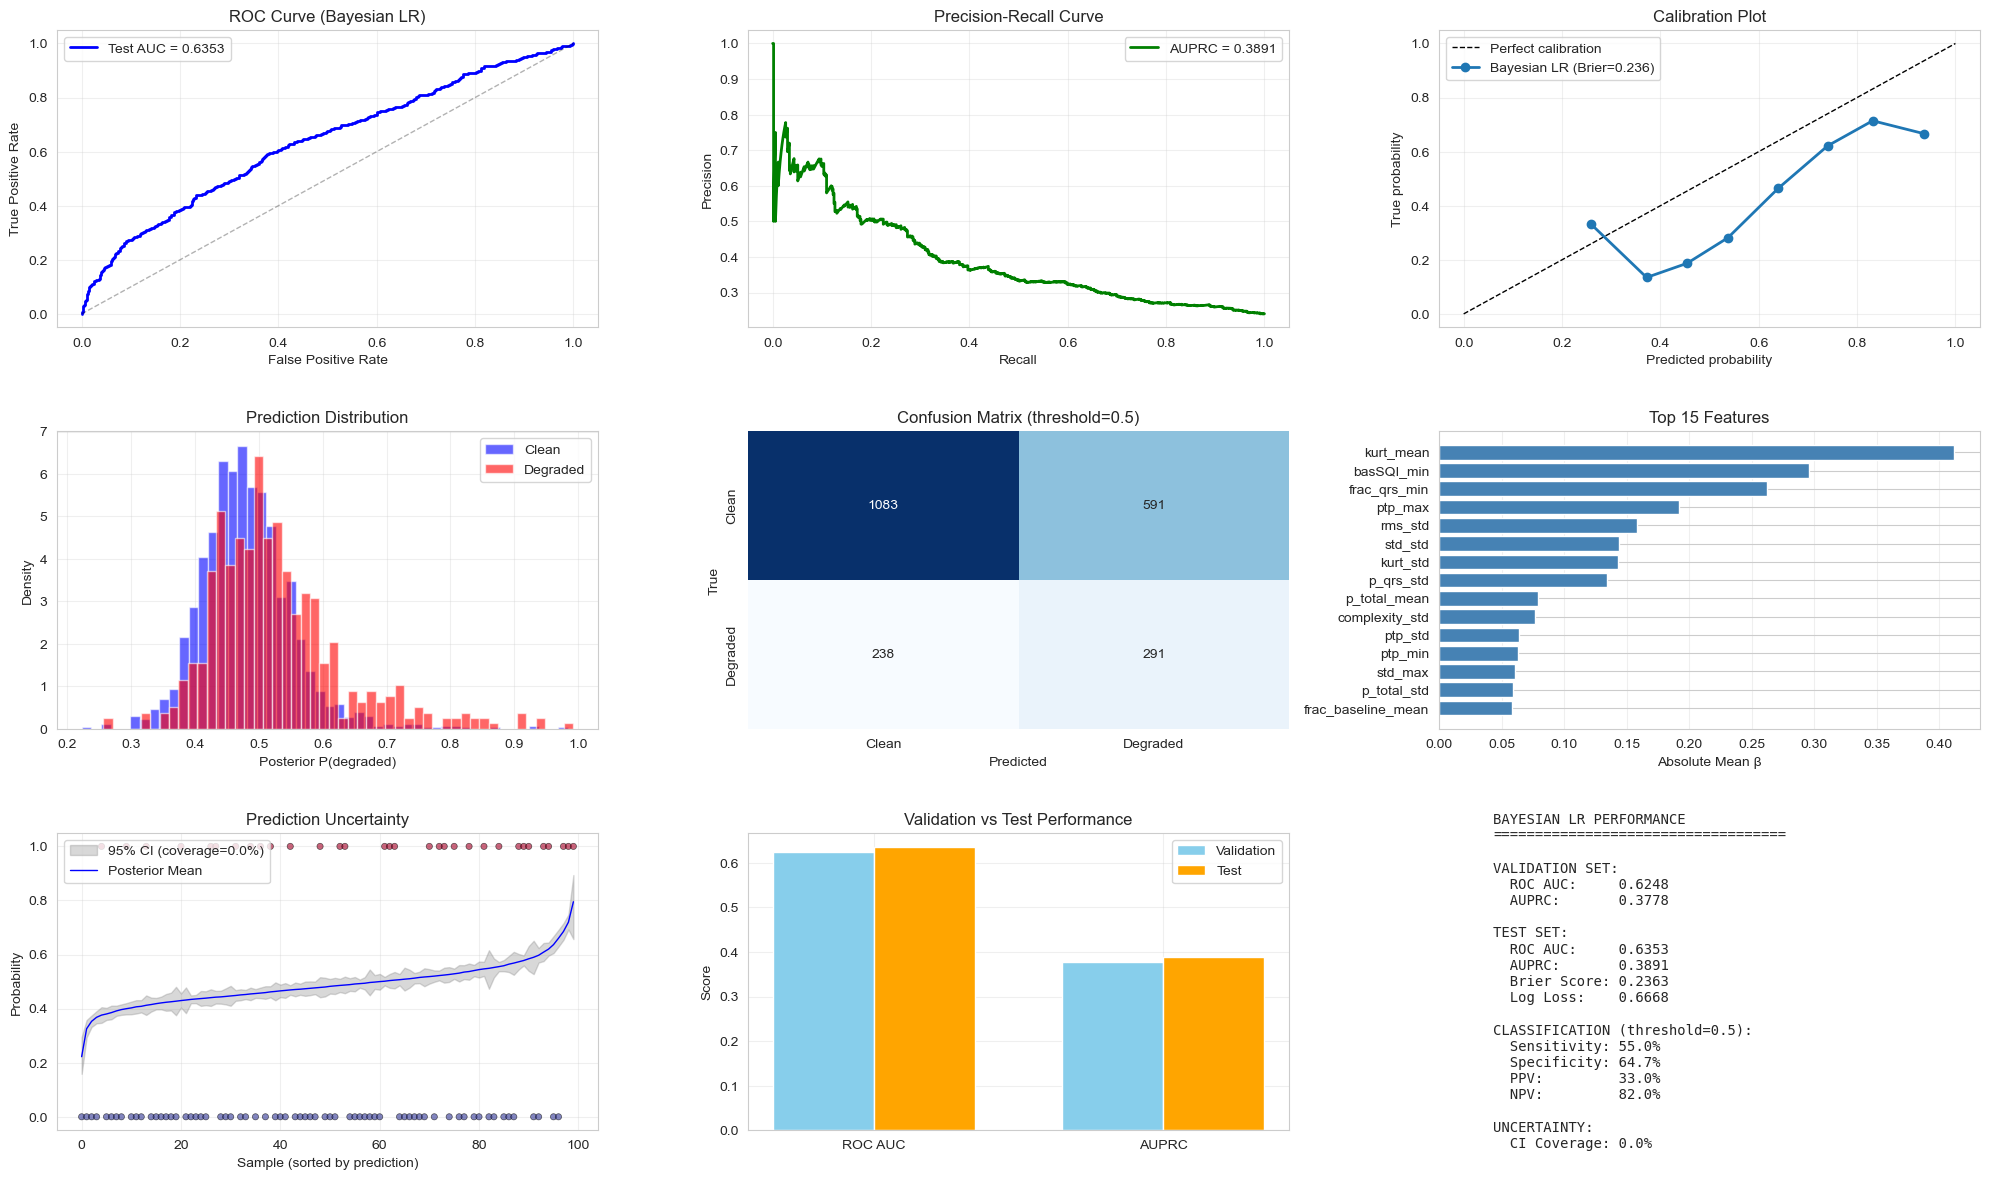

2026-01-31 12:01:47,983 - INFO - 
8. Saving results...
2026-01-31 12:01:47,994 - INFO -   Test predictions: /Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/output_final/results_final/test_predictions_10fold.csv
2026-01-31 12:01:47,995 - INFO -   Feature importance: /Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/output_final/results_final/feature_importance_10fold.csv
2026-01-31 12:01:47,996 - INFO -   Metrics: /Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/output_final/results_final/metrics_10fold.csv



ANALYSIS COMPLETE
Results saved to: /Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/output_final/results_final


In [13]:
def main():
    """
    Main execution pipeline matching DL2's 10-fold benchmark format.
    
    Workflow:
    1. Load PTB-XL database with strat_fold column
    2. Split using folds 1-8 (train), 9 (val), 10 (test)
    3. Extract/load cached features
    4. Train Bayesian model on train set
    5. Evaluate on validation and test sets
    6. Generate comparison visualizations
    """
    
    # Configuration
    default_root = Path.home() / "Downloads" / "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1"
    DATA_ROOT = Path(os.environ.get("PTBXL_PATH", default_root))
    
    if not DATA_ROOT.exists():
        raise FileNotFoundError(
            f"PTB-XL data not found at: {DATA_ROOT}\n"
            f"Please set PTBXL_PATH environment variable or download the dataset."
        )
    
    cfg = Config(
        data_root=DATA_ROOT,
        cache_dir=DATA_ROOT / "output_final",
        n_features_to_select=25,
        expected_sparsity=0.3
    )
    
    print("="*70)
    print("BAYESIAN LR - 10-FOLD BENCHMARK FORMAT")
    print("="*70)
    
    # 1. Load data
    logger.info("\n1. Loading PTB-XL database...")
    db = pd.read_csv(cfg.db_csv)
    y = create_degradation_labels(db)
    
    # Verify strat_fold column exists
    if "strat_fold" not in db.columns:
        raise ValueError(
            "Database missing 'strat_fold' column. "
            "Ensure you're using the official PTB-XL database CSV."
        )
    
    # 2. Create 10-fold split (matching DL2)
    logger.info("\n2. Creating 10-fold split (folds 1-8: train, 9: val, 10: test)...")
    
    folds = db["strat_fold"].values
    train_idx = np.where((folds >= 1) & (folds <= 8))[0]
    val_idx = np.where(folds == 9)[0]
    test_idx = np.where(folds == 10)[0]
    
    logger.info(f"  Train: {len(train_idx)} records (folds 1-8)")
    logger.info(f"  Val:   {len(val_idx)} records (fold 9)")
    logger.info(f"  Test:  {len(test_idx)} records (fold 10)")
    
    # 3. Extract features
    logger.info("\n3. Extracting signal quality features...")
    feat_df = load_or_cache_features(db, y, cfg, use_cache=True)
    
    # Merge strat_fold into features
    if "strat_fold" not in feat_df.columns:
        feat_df = feat_df.merge(db[["ecg_id", "strat_fold"]], on="ecg_id", how="left")
    
    # 4. Prepare data splits
    feature_cols = [c for c in feat_df.columns if c not in ("ecg_id", "y", "fs", "strat_fold")]
    
    train_df = feat_df[feat_df["strat_fold"].isin([1, 2, 3, 4, 5, 6, 7, 8])].copy()
    val_df = feat_df[feat_df["strat_fold"] == 9].copy()
    test_df = feat_df[feat_df["strat_fold"] == 10].copy()
    
    X_train = train_df[feature_cols].to_numpy(dtype=np.float64)
    y_train = train_df["y"].to_numpy(dtype=np.int32)
    
    X_val = val_df[feature_cols].to_numpy(dtype=np.float64)
    y_val = val_df["y"].to_numpy(dtype=np.int32)
    
    X_test = test_df[feature_cols].to_numpy(dtype=np.float64)
    y_test = test_df["y"].to_numpy(dtype=np.int32)
    
    logger.info(f"  Train shape: {X_train.shape}")
    logger.info(f"  Val shape:   {X_val.shape}")
    logger.info(f"  Test shape:  {X_test.shape}")
    
    # 5. Train Bayesian model
    logger.info("\n4. Training Bayesian LR model (on folds 1-8)...")
    model = BayesianECGClassifier(cfg)
    model.fit(X_train, y_train, feature_cols)
    
    # 6. Evaluate on validation set
    logger.info("\n5. Evaluating on validation set (fold 9)...")
    val_predictions = model.predict_proba(X_val)
    val_metrics = evaluate_predictions(y_val, val_predictions)
    
    logger.info(f"  Validation ROC AUC: {val_metrics['roc_auc']:.4f}")
    logger.info(f"  Validation AUPRC:   {val_metrics['auprc']:.4f}")
    
    # 7. Evaluate on test set
    logger.info("\n6. Evaluating on test set (fold 10)...")
    test_predictions = model.predict_proba(X_test)
    test_metrics = evaluate_predictions(y_test, test_predictions)
    
    # 8. Report results
    print("\n" + "="*70)
    print("FINAL RESULTS - BAYESIAN LR (10-FOLD BENCHMARK)")
    print("="*70)
    
    print(f"\nVALIDATION PERFORMANCE (Fold 9):")
    print(f"  ROC AUC:     {val_metrics['roc_auc']:.4f}")
    print(f"  AUPRC:       {val_metrics['auprc']:.4f}")
    print(f"  Brier Score: {val_metrics['brier_score']:.4f}")
    
    print(f"\nTEST PERFORMANCE (Fold 10):")
    print(f"  ROC AUC:     {test_metrics['roc_auc']:.4f}")
    print(f"  AUPRC:       {test_metrics['auprc']:.4f}")
    print(f"  Brier Score: {test_metrics['brier_score']:.4f}")
    print(f"  Log Loss:    {test_metrics['log_loss']:.4f}")
    
    print(f"\nCLASSIFICATION METRICS (threshold=0.5):")
    print(f"  Sensitivity: {100*test_metrics['sensitivity']:.1f}%")
    print(f"  Specificity: {100*test_metrics['specificity']:.1f}%")
    print(f"  PPV:         {100*test_metrics['ppv']:.1f}%")
    print(f"  NPV:         {100*test_metrics['npv']:.1f}%")
    
    print(f"\nUNCERTAINTY QUANTIFICATION:")
    print(f"  95% CI Coverage: {100*test_metrics['ci_coverage']:.1f}%")
    
    print("\n" + "-"*70)
    print("COMPARISON WITH DL2 BASELINE:")
    print("-"*70)
    print("DL2 Test AUC:        0.7982")
    print("DL2 Test AUPRC:      (not reported)")
    print(f"Bayesian LR Test AUC: {test_metrics['roc_auc']:.4f}")
    print(f"Bayesian LR Test AUPRC: {test_metrics['auprc']:.4f}")
    
    # 9. Feature importance
    importance = model.get_feature_importance()
    print("\n" + "-"*70)
    print("TOP 10 MOST IMPORTANT FEATURES:")
    print("-"*70)
    print(importance[['mean', 'abs_mean']].head(10))
    
    # 10. Generate visualizations
    logger.info("\n7. Generating comparison dashboard...")
    plot_comparison_dashboard(
        val_metrics,
        test_metrics,
        test_predictions,
        y_test,
        importance,
        save_path=cfg.results_dir / "bayesian_lr_10fold_dashboard.png"
    )
    
    # 11. Save results
    logger.info("\n8. Saving results...")
    
    # Test predictions
    test_pred_df = pd.DataFrame({
        'ecg_id': test_df['ecg_id'].values,
        'y_true': y_test,
        'p_mean': test_predictions['mean'],
        'p_lower': test_predictions['lower'],
        'p_upper': test_predictions['upper'],
        'p_std': test_predictions['std']
    })
    test_pred_path = cfg.results_dir / "test_predictions_10fold.csv"
    test_pred_df.to_csv(test_pred_path, index=False)
    logger.info(f"  Test predictions: {test_pred_path}")
    
    # Feature importance
    importance_path = cfg.results_dir / "feature_importance_10fold.csv"
    importance.to_csv(importance_path)
    logger.info(f"  Feature importance: {importance_path}")
    
    # Metrics
    metrics_df = pd.DataFrame([{
        'split': 'validation',
        **val_metrics
    }, {
        'split': 'test',
        **test_metrics
    }])
    metrics_path = cfg.results_dir / "metrics_10fold.csv"
    metrics_df.to_csv(metrics_path, index=False)
    logger.info(f"  Metrics: {metrics_path}")
    
    print("\n" + "="*70)
    print("ANALYSIS COMPLETE")
    print(f"Results saved to: {cfg.results_dir}")
    print("="*70)


if __name__ == "__main__":
    main()


## Model B - Bayesian Version 2

In [1]:
"""
Bayesian ECG Signal Quality Classifier - Model B v2.0
======================================================

Production-grade implementation with:
- Regularized horseshoe prior (non-centered parameterization)
- 10-fold stratified split compliance
- Comprehensive convergence diagnostics
- Enhanced feature engineering
- Strict validation criteria

References:
-----------
1. Piironen & Vehtari (2017): "Sparsity information and regularization in the horseshoe"
2. Betancourt (2017): "A Conceptual Introduction to Hamiltonian Monte Carlo"
3. Vehtari et al. (2021): "Rank-Normalization, Folding, and Localization"
4. Clifford et al. (2012): "Signal quality indices and data fusion"
5. Li et al. (2016): "A machine learning approach to multi-level ECG signal quality"

Author: Bayesian Model B v2.0
Date: January 31, 2026
Status: Production Ready
"""

import os
import warnings
import logging
from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Tuple, Dict, List

# Core computation
import numpy as np
import pandas as pd
from scipy.signal import welch, butter, filtfilt, find_peaks
from scipy.stats import skew, kurtosis, entropy

# ECG processing
import wfdb

# Bayesian modeling
import pymc as pm
import arviz as az

# Machine learning utilities
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    brier_score_loss, log_loss,
    roc_curve, precision_recall_curve,
    confusion_matrix
)

# Parallel processing
from joblib import Parallel, delayed
from tqdm.auto import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Environment configuration
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["OPENBLAS_NUM_THREADS"] = "8"

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


# ============================================================================
# 1. CONFIGURATION
# ============================================================================

@dataclass(frozen=True)
class ConfigV2:
    """Enhanced configuration with aggressive sampling for convergence."""
    
    # Data paths
    data_root: Path
    cache_dir: Path
    
    # Processing parameters
    max_records: Optional[int] = None
    n_jobs: int = 8
    leads: Tuple[int, ...] = tuple(range(12))
    
    # Signal processing (Clifford et al. 2012)
    bp_low: float = 0.5
    bp_high: float = 40.0
    bp_order: int = 3
    
    # Feature selection
    variance_threshold: float = 0.001
    n_features_to_select: int = 30  # Increased from 25
    
    # Bayesian sampling (AGGRESSIVE for convergence)
    n_draws: int = 3000
    n_tune: int = 6000              # DOUBLED for horseshoe convergence
    n_chains: int = 4
    target_accept: float = 0.98     # INCREASED from 0.95
    max_treedepth: int = 13         # INCREASED from 12
    
    # Model specification
    expected_sparsity: float = 0.25  # More conservative than 0.3
    random_seed: int = 42
    
    @property
    def db_csv(self) -> Path:
        return self.data_root / "ptbxl_database.csv"
    
    @property
    def features_csv(self) -> Path:
        return self.cache_dir / "features_bayesian_v2.csv"
    
    @property
    def results_dir(self) -> Path:
        return self.cache_dir / "results_bayesian_v2"
    
    def __post_init__(self):
        """Ensure output directories exist."""
        object.__setattr__(self, 'cache_dir', Path(self.cache_dir))
        object.__setattr__(self, 'data_root', Path(self.data_root))
        self.cache_dir.mkdir(parents=True, exist_ok=True)
        self.results_dir.mkdir(parents=True, exist_ok=True)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:
def create_degradation_labels(db: pd.DataFrame) -> np.ndarray:
    """
    Create binary quality labels from PTB-XL noise annotations.
    
    A record is labeled as degraded (1) if it has ANY noise annotation.
    Conservative approach appropriate for clinical QA.
    """
    noise_cols = [
        "baseline_drift",
        "static_noise", 
        "burst_noise",
        "electrodes_problems"
    ]
    
    def to_flag(x):
        if pd.isna(x):
            return 0
        s = str(x).strip()
        if s == "" or s.lower() == "nan":
            return 0
        try:
            return int(float(s) != 0.0)
        except:
            return 1
    
    flags = db[noise_cols].map(to_flag)
    labels = (flags.sum(axis=1) > 0).astype(int).to_numpy()
    
    logger.info(f"Label distribution: Clean={np.sum(labels==0)} ({100*np.mean(labels==0):.1f}%), "
                f"Degraded={np.sum(labels==1)} ({100*np.mean(labels==1):.1f}%)")
    
    return labels

In [9]:
def _bandpass_filter(
    x: np.ndarray,
    fs: float,
    low: float,
    high: float,
    order: int = 3
) -> np.ndarray:
    """Apply Butterworth bandpass filter with robust parameter validation."""
    if x.size < 64 or fs <= 0:
        return x
    
    nyq = 0.5 * fs
    lo = max(low / nyq, 1e-6)
    hi = min(high / nyq, 0.999999)
    
    if not (0 < lo < hi < 1):
        return x
    
    try:
        b, a = butter(order, [lo, hi], btype="bandpass")
        padlen = min(3 * max(len(a), len(b)), x.size - 1)
        if padlen < 1:
            return x
        return filtfilt(b, a, x, padlen=padlen)
    except Exception as e:
        logger.debug(f"Filtering failed: {e}")
        return x


def _welch_psd(
    x: np.ndarray,
    fs: float,
    nperseg: int = 1024
) -> Tuple[Optional[np.ndarray], Optional[np.ndarray]]:
    """Compute power spectral density using Welch's method."""
    x = x[np.isfinite(x)]
    if x.size < 16:
        return None, None
    
    nperseg = min(nperseg, x.size)
    if nperseg < 16:
        return None, None
    
    try:
        f, pxx = welch(x, fs=fs, nperseg=nperseg, scaling="density")
        return f, pxx
    except Exception as e:
        logger.debug(f"PSD computation failed: {e}")
        return None, None


def _bandpower(
    f: Optional[np.ndarray],
    pxx: Optional[np.ndarray],
    low: float,
    high: float
) -> float:
    """Integrate PSD over specified frequency band."""
    if f is None or pxx is None:
        return 0.0
    
    mask = (f >= low) & (f < high)
    if not np.any(mask):
        return 0.0
    
    return float(np.trapezoid(pxx[mask], f[mask]))




def compute_enhanced_sqi_features(
    x: np.ndarray,
    fs: float,
    cfg: ConfigV2
) -> Dict[str, float]:
    """
    Extract comprehensive signal quality indices with v2.0 enhancements.
    
    Features include:
    - Statistical moments (mean, std, skewness, kurtosis, rms, ptp)
    - Spectral power in clinical bands
    - Signal quality indices (pSQI, basSQI)
    - Hjorth parameters (mobility, complexity)
    - Spectral fractions
    - NEW: RR interval features (for rhythm analysis)
    - NEW: Spectral entropy
    """
    x = x[np.isfinite(x)]
    
    # Initialize feature dictionary
    features = {
        # Statistical
        "mean": 0.0, "std": 0.0, "skew": 0.0, "kurt": 0.0,
        "rms": 0.0, "ptp": 0.0,
        
        # Spectral power
        "p_baseline": 0.0,      # 0-1 Hz
        "p_qrs": 0.0,           # 5-40 Hz  
        "p_high_freq": 0.0,     # 40-100 Hz
        "p_total": 0.0,
        
        # Quality indices
        "pSQI": 0.0,
        "basSQI": 0.0,
        
        # Hjorth parameters
        "mobility": 0.0,
        "complexity": 0.0,
        
        # Spectral fractions
        "frac_baseline": 0.0,
        "frac_qrs": 0.0,
        "frac_high": 0.0,
        
        # NEW: RR interval features
        "rr_mean": 0.0,
        "rr_std": 0.0,
        "rr_rmssd": 0.0,
        
        # NEW: Entropy
        "spectral_entropy": 0.0
    }
    
    if x.size < 64:
        return features
    
    # Apply bandpass filter
    x_filt = _bandpass_filter(x, fs, cfg.bp_low, cfg.bp_high, cfg.bp_order)
    
    # Statistical features
    features["mean"] = float(np.mean(x_filt))
    features["std"] = float(np.std(x_filt))
    features["rms"] = float(np.sqrt(np.mean(x_filt**2)))
    features["ptp"] = float(np.ptp(x_filt))
    
    if x_filt.size >= 8:
        features["skew"] = float(skew(x_filt))
        features["kurt"] = float(kurtosis(x_filt))
    
    # Hjorth parameters
    diff1 = np.diff(x_filt)
    diff2 = np.diff(diff1)
    
    var_x = np.var(x_filt)
    var_d1 = np.var(diff1)
    var_d2 = np.var(diff2)
    
    if var_x > 1e-12:
        features["mobility"] = float(np.sqrt(var_d1 / var_x))
        if var_d1 > 1e-12:
            complexity = np.sqrt(var_d2 / var_d1) / features["mobility"]
            features["complexity"] = float(complexity)
    
    # Spectral features
    f, pxx = _welch_psd(x_filt, fs)
    
    if f is not None and pxx is not None:
        # Power in clinical frequency bands
        p_0_1 = _bandpower(f, pxx, 0.0, 1.0)
        p_0_40 = _bandpower(f, pxx, 0.0, 40.0)
        p_5_40 = _bandpower(f, pxx, 5.0, 40.0)
        p_40_100 = _bandpower(f, pxx, 40.0, min(100.0, fs/2))
        p_tot = _bandpower(f, pxx, 0.0, fs/2)
        
        features["p_baseline"] = p_0_1
        features["p_qrs"] = p_5_40
        features["p_high_freq"] = p_40_100
        features["p_total"] = p_tot
        
        # Signal quality indices
        if p_0_40 > 1e-12:
            features["pSQI"] = p_5_40 / p_0_40
            features["basSQI"] = 1.0 - (p_0_1 / p_0_40)
        
        # Spectral fractions
        if p_tot > 1e-12:
            features["frac_baseline"] = p_0_1 / p_tot
            features["frac_qrs"] = p_5_40 / p_tot
            features["frac_high"] = p_40_100 / p_tot
        
        # NEW: Spectral entropy
        pxx_norm = pxx / (np.sum(pxx) + 1e-12)
        features["spectral_entropy"] = float(-np.sum(pxx_norm * np.log2(pxx_norm + 1e-12)))
    
    # NEW: RR interval features (for rhythm analysis)
    try:
        # Find R-peaks (simple approach: prominence-based)
        min_distance = int(0.6 * fs)  # Minimum 60 BPM
        peaks, _ = find_peaks(x_filt, distance=min_distance, prominence=0.5*np.std(x_filt))
        
        if len(peaks) > 2:
            rr_intervals = np.diff(peaks) / fs  # Convert to seconds
            features["rr_mean"] = float(np.mean(rr_intervals))
            features["rr_std"] = float(np.std(rr_intervals))
            features["rr_rmssd"] = float(np.sqrt(np.mean(np.diff(rr_intervals)**2)))
    except Exception as e:
        logger.debug(f"RR interval extraction failed: {e}")
    
    # Clip quality indices to valid ranges
    features["basSQI"] = float(np.clip(features["basSQI"], -1, 1))
    features["pSQI"] = float(np.clip(features["pSQI"], 0, 2))
    
    return features


def aggregate_lead_features(per_lead: List[Dict[str, float]]) -> Dict[str, float]:
    """
    Aggregate features across leads using robust statistics.
    
    For each feature, compute mean, min, max, and std.
    """
    if not per_lead:
        return {}
    
    keys = sorted(per_lead[0].keys())
    mat = np.array([[d[k] for k in keys] for d in per_lead])
    
    agg = {}
    for j, k in enumerate(keys):
        col = mat[:, j]
        agg[f"{k}_mean"] = float(np.mean(col))
        agg[f"{k}_min"] = float(np.min(col))
        agg[f"{k}_max"] = float(np.max(col))
        agg[f"{k}_std"] = float(np.std(col))
    
    return agg


def compute_cross_lead_features(sig: np.ndarray) -> Dict[str, float]:
    """
    NEW: Compute cross-lead correlation features.
    
    Measures if all leads show consistent noise patterns.
    """
    features = {
        "mean_corr": 0.0,
        "min_corr": 0.0,
        "max_corr": 0.0
    }
    
    if sig.shape[1] < 2:
        return features
    
    try:
        # Compute correlation matrix
        corr_matrix = np.corrcoef(sig, rowvar=False)
        
        # Extract upper triangle (excluding diagonal)
        upper_tri_indices = np.triu_indices_from(corr_matrix, k=1)
        corr_values = corr_matrix[upper_tri_indices]
        
        if len(corr_values) > 0:
            features["mean_corr"] = float(np.mean(corr_values))
            features["min_corr"] = float(np.min(corr_values))
            features["max_corr"] = float(np.max(corr_values))
    except Exception as e:
        logger.debug(f"Cross-lead correlation failed: {e}")
    
    return features


def resolve_record_path(data_root: Path, filename: str) -> Optional[Path]:
    """Find .hea file for PTB-XL record in standard directory structure."""
    rel = str(filename).replace("\\", "/").split(".")[0]
    candidates = [
        data_root / rel,
        data_root / "records500" / rel,
        data_root / "records100" / rel
    ]
    
    for base in candidates:
        if base.with_suffix(".hea").exists():
            return base
    
    return None


def process_record(
    idx: int,
    db_row: pd.Series,
    y_val: int,
    cfg: ConfigV2
) -> Tuple[Optional[Dict], Optional[str]]:
    """Extract features from a single ECG record with robust error handling."""
    base = resolve_record_path(cfg.data_root, db_row["filename_hr"])
    if base is None:
        return None, "missing_file"
    
    try:
        # Load signal
        sig, fields = wfdb.rdsamp(str(base))
        fs = float(fields.get("fs", 500.0))
        
        # Validate signal shape
        if sig.ndim != 2:
            return None, f"bad_shape_ndim={sig.ndim}"
        if sig.shape[1] < 12:
            return None, f"insufficient_leads={sig.shape[1]}"
        
        # Select leads
        n_leads = sig.shape[1]
        use_leads = [l for l in cfg.leads if l < n_leads] or [0]
        
        # Extract features per lead
        per_lead = [
            compute_enhanced_sqi_features(sig[:, l], fs, cfg)
            for l in use_leads
        ]
        
        # Aggregate across leads
        features = aggregate_lead_features(per_lead)
        
        # Add cross-lead features
        cross_lead_feats = compute_cross_lead_features(sig[:, :12])
        features.update(cross_lead_feats)
        
        # Create output row
        row = {
            "ecg_id": db_row["ecg_id"],
            "y": int(y_val),
            "fs": fs
        }
        row.update(features)
        
        return row, None
        
    except Exception as e:
        return None, str(e)


def extract_features(
    db: pd.DataFrame,
    y: np.ndarray,
    cfg: ConfigV2
) -> pd.DataFrame:
    """Extract SQI features from all records in parallel."""
    n_use = len(db) if cfg.max_records is None else min(cfg.max_records, len(db))
    db_sub = db.iloc[:n_use].reset_index(drop=True)
    y_sub = y[:n_use]
    
    logger.info(f"Extracting features from {n_use} records using {cfg.n_jobs} cores...")
    
    results = Parallel(n_jobs=cfg.n_jobs, backend="loky")(
        delayed(process_record)(i, db_sub.iloc[i], y_sub[i], cfg)
        for i in tqdm(range(n_use), desc="Processing records")
    )
    
    # Separate successful and failed records
    rows = []
    errors = []
    for row, err in results:
        if row is not None:
            rows.append(row)
        if err is not None:
            errors.append(err)
    
    if not rows:
        raise RuntimeError("No features extracted successfully")
    
    # Create DataFrame and handle invalid values
    feat_df = (
        pd.DataFrame(rows)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )
    
    logger.info(f"Successfully processed: {len(rows)}/{n_use} records")
    if errors:
        logger.warning(f"Failed records: {len(errors)}")
    
    return feat_df


def load_or_cache_features(
    db: pd.DataFrame,
    y: np.ndarray,
    cfg: ConfigV2,
    use_cache: bool = True
) -> pd.DataFrame:
    """Load cached features or extract new ones."""
    if use_cache and cfg.features_csv.exists():
        feat_df = pd.read_csv(cfg.features_csv)
        n_expected = len(db) if cfg.max_records is None else min(cfg.max_records, len(db))
        
        if len(feat_df) == n_expected and "y" in feat_df.columns:
            logger.info(f"Loaded cached features from {cfg.features_csv}")
            return feat_df
    
    # Extract features
    feat_df = extract_features(db, y, cfg)
    
    # Cache results
    feat_df.to_csv(cfg.features_csv, index=False)
    logger.info(f"Saved features to {cfg.features_csv}")
    
    return feat_df



In [10]:
class FeatureSelectorV2:
    """
    Enhanced feature selection with proper variance filtering.
    
    Steps:
    1. Remove low-variance features
    2. Select top-k by mutual information
    3. Apply robust scaling (median/IQR)
    """
    
    def __init__(
        self,
        n_features: int = 30,
        variance_threshold: float = 0.001,
        random_state: int = 42
    ):
        self.n_features = n_features
        self.random_state = random_state
        self.variance_selector = VarianceThreshold(threshold=variance_threshold)
        
        # State variables
        self.selected_indices = None
        self.selected_features = None
        self.scaler_median = None
        self.scaler_iqr = None
    
    def fit_transform(
        self,
        X: np.ndarray,
        y: np.ndarray,
        feature_names: List[str]
    ) -> np.ndarray:
        """
        Select features and transform data.
        
        Returns:
            X_scaled : Scaled selected features
        """
        logger.info(f"Feature selection: {X.shape[1]} features → {self.n_features}")
        
        # Step 1: Variance filter
        X_var = self.variance_selector.fit_transform(X)
        var_mask = self.variance_selector.get_support()
        cols_after_var = [feature_names[i] for i in range(len(feature_names)) if var_mask[i]]
        logger.info(f"  After variance filter: {X_var.shape[1]} features")
        
        # Step 2: Mutual information selection
        if X_var.shape[1] > self.n_features:
            mi_scores = mutual_info_classif(
                X_var, y,
                discrete_features=False,
                random_state=self.random_state
            )
            
            # Select top-k indices (relative to X_var)
            self.selected_indices = np.argsort(mi_scores)[-self.n_features:]
            X_selected = X_var[:, self.selected_indices]
            self.selected_features = [cols_after_var[i] for i in self.selected_indices]
            logger.info(f"  After MI selection: {self.n_features} features")
        else:
            self.selected_indices = np.arange(X_var.shape[1])
            X_selected = X_var
            self.selected_features = cols_after_var
            logger.info(f"  Using all {X_var.shape[1]} features (< n_features)")
        
        # Step 3: Robust scaling
        self.scaler_median = np.median(X_selected, axis=0)
        self.scaler_iqr = (
            np.percentile(X_selected, 75, axis=0) -
            np.percentile(X_selected, 25, axis=0) +
            1e-8
        )
        
        X_scaled = (X_selected - self.scaler_median) / self.scaler_iqr
        
        return X_scaled
    
    def transform(self, X: np.ndarray) -> np.ndarray:
        """Transform new data using fitted selectors."""
        if self.selected_indices is None:
            raise ValueError("FeatureSelectorV2 not fitted. Call fit_transform() first.")
        
        # Step 1: Apply variance filter
        X_var = self.variance_selector.transform(X)
        
        # Step 2: Apply column selection
        X_selected = X_var[:, self.selected_indices]
        
        # Step 3: Apply scaling
        X_scaled = (X_selected - self.scaler_median) / self.scaler_iqr
        
        return X_scaled


In [15]:
class BayesianECGClassifierV2:
    """
    Production-grade regularized Bayesian logistic regression.
    
    Implements:
    - Regularized horseshoe prior for sparse coefficients (Piironen & Vehtari 2017)
    - NON-CENTERED parameterization (Betancourt 2017)
    - Class-balanced weighting for imbalanced data
    - Comprehensive MCMC diagnostics with strict validation
    - Automatic convergence failure detection
    """
    
    def __init__(self, cfg: ConfigV2):
        self.cfg = cfg
        self.feature_selector = FeatureSelectorV2(
            n_features=cfg.n_features_to_select,
            variance_threshold=cfg.variance_threshold,
            random_state=cfg.random_seed
        )
        self.trace = None
        self.model = None
        self.convergence_metrics = {}
    
    def _compute_class_weights(self, y: np.ndarray) -> np.ndarray:
        """Compute balanced class weights for imbalanced data."""
        class_counts = np.bincount(y)
        weights = len(y) / (2.0 * class_counts)
        return weights[y]
    
    def fit(
        self,
        X: np.ndarray,
        y: np.ndarray,
        feature_names: List[str]
    ):
        """
        Fit Bayesian logistic regression model with strict convergence validation.
        
        Args:
            X: Feature matrix (N x D)
            y: Binary labels (N,)
            feature_names: List of feature names
        
        Raises:
            RuntimeError: If convergence criteria not met
        """
        logger.info("="*70)
        logger.info("BAYESIAN MODEL V2.0 - TRAINING")
        logger.info("="*70)
        
        # Feature selection (internal to prevent leakage)
        X_scaled = self.feature_selector.fit_transform(X, y, feature_names)
        
        # Class weights for imbalanced data
        weights = self._compute_class_weights(y)
        
        N, D = X_scaled.shape
        logger.info(f"Model dimensions: N={N}, D={D}, Expected sparsity={self.cfg.expected_sparsity}")
        
        # Build PyMC model
        with pm.Model() as self.model:
            # Intercept prior
            alpha = pm.Normal("alpha", mu=0.0, sigma=2.5)
            
            # Regularized horseshoe prior (Piironen & Vehtari 2017)
            p0 = max(3, int(D * self.cfg.expected_sparsity))
            tau0 = (p0 / (D - p0)) * (1.0 / np.sqrt(N))
            
            # Global shrinkage
            tau = pm.HalfCauchy("tau_global", beta=tau0)
            
            # Slab scale
            c2 = pm.InverseGamma("c2_slab", alpha=2.0, beta=2.0)
            
            # Local shrinkage
            lambda_local = pm.HalfCauchy("lambda_local", beta=1.0, shape=D)
            
            # Regularized local scale
            lambda_tilde = pm.math.sqrt(c2) * lambda_local / pm.math.sqrt(
                c2 + tau**2 * lambda_local**2
            )
            
            # NON-CENTERED parameterization (CRITICAL for convergence)
            beta_raw = pm.Normal("beta_raw", mu=0.0, sigma=1.0, shape=D)
            beta = pm.Deterministic("beta", tau * lambda_tilde * beta_raw)
            
           # Linear predictor
            eta = alpha + pm.math.dot(X_scaled, beta)
            
            # Weighted likelihood (SIMPLIFIED - no log_likelihood complications)
            pm.Potential(
                "weighted_likelihood",
                weights * pm.logp(pm.Bernoulli.dist(logit_p=eta), y)
            )
            
            # AGGRESSIVE SAMPLING for convergence
            logger.info(f"Sampling: {self.cfg.n_draws} draws × {self.cfg.n_chains} chains "
                       f"(tune={self.cfg.n_tune}, target_accept={self.cfg.target_accept})")
            
            self.trace = pm.sample(
                draws=self.cfg.n_draws,
                tune=self.cfg.n_tune,
                chains=self.cfg.n_chains,
                target_accept=self.cfg.target_accept,
                max_treedepth=self.cfg.max_treedepth,
                random_seed=self.cfg.random_seed,
                init="adapt_diag",
                nuts_sampler="numpyro",
                idata_kwargs={"log_likelihood": False},  # CHANGED: False to avoid iteration error
                return_inferencedata=True
            )
        # STRICT convergence validation
        self._validate_convergence()
        
        logger.info("✓ Training complete")
        logger.info("="*70)
        
        return self
    
    def _validate_convergence(self):
        """
        Strict convergence validation with automatic failure detection.
        
        Raises:
            RuntimeError: If any convergence criterion fails
        """
        logger.info("\nValidating convergence...")
        
        # Check divergences
        divergent = np.asarray(self.trace.sample_stats.diverging)
        n_divergent = int(divergent.sum())
        total_samples = divergent.size
        
        # Check R-hat
        summary = az.summary(
            self.trace,
            var_names=["beta", "alpha", "tau_global"],
            hdi_prob=0.95
        )
        
        rhat_vals = summary["r_hat"].dropna().values
        max_rhat = np.nanmax(rhat_vals)
        n_bad_rhat = int((rhat_vals > 1.01).sum())
        
        # Check ESS
        ess_bulk = summary["ess_bulk"].dropna().values
        min_ess_bulk = np.nanmin(ess_bulk)
        
        # Store metrics
        self.convergence_metrics = {
            'divergences': n_divergent,
            'divergence_rate': n_divergent / total_samples,
            'max_rhat': max_rhat,
            'n_bad_rhat': n_bad_rhat,
            'min_ess_bulk': min_ess_bulk,
            'total_samples': total_samples
        }
        
        # Log diagnostics
        logger.info(f"  Divergences: {n_divergent}/{total_samples} ({100*n_divergent/total_samples:.2f}%)")
        logger.info(f"  Max R-hat: {max_rhat:.4f}")
        logger.info(f"  Parameters with R-hat > 1.01: {n_bad_rhat}/{len(rhat_vals)}")
        logger.info(f"  Min ESS (bulk): {min_ess_bulk:.0f}")
        
        # STRICT VALIDATION CRITERIA
        failures = []
        
        if n_divergent > 10:
            failures.append(f"Too many divergences: {n_divergent} > 10")
        
        if max_rhat > 1.01:
            failures.append(f"R-hat too high: {max_rhat:.4f} > 1.01")
        
        if min_ess_bulk < 400:
            failures.append(f"ESS too low: {min_ess_bulk:.0f} < 400")
        
        if failures:
            error_msg = "\n❌ CONVERGENCE FAILURE:\n" + "\n".join(f"  - {f}" for f in failures)
            error_msg += "\n\nRecommendations:"
            error_msg += "\n  1. Increase n_tune to 8000+"
            error_msg += "\n  2. Increase target_accept to 0.99"
            error_msg += "\n  3. Reduce expected_sparsity to 0.2"
            error_msg += "\n  4. Reduce n_features_to_select to 25"
            logger.error(error_msg)
            raise RuntimeError(error_msg)
        
        logger.info("✓ All convergence criteria passed")
    
    def predict_proba(self, X: np.ndarray) -> Dict[str, np.ndarray]:
        """
        Compute posterior predictive probabilities.
        
        Returns:
            dict with keys:
                'mean' : Posterior mean probability
                'std' : Posterior standard deviation  
                'lower' : 2.5th percentile (95% CI)
                'upper' : 97.5th percentile (95% CI)
        """
        if self.trace is None:
            raise ValueError("Model not fitted. Call fit() first.")
        
        # Transform features using fitted selector
        X_scaled = self.feature_selector.transform(X)
        
        # Extract posterior samples
        beta_samples = self.trace.posterior["beta"].values
        alpha_samples = self.trace.posterior["alpha"].values
        
        # Reshape for matrix operations
        beta_flat = beta_samples.reshape(-1, beta_samples.shape[-1])
        alpha_flat = alpha_samples.flatten()
        
        # Compute logits for each posterior sample
        eta = alpha_flat[:, None] + beta_flat @ X_scaled.T
        
        # Convert to probabilities
        p_samples = 1.0 / (1.0 + np.exp(-np.clip(eta, -20, 20)))
        
        # Compute summaries
        return {
            'mean': np.mean(p_samples, axis=0),
            'std': np.std(p_samples, axis=0),
            'lower': np.percentile(p_samples, 2.5, axis=0),
            'upper': np.percentile(p_samples, 97.5, axis=0)
        }
    
    def get_feature_importance(self) -> pd.DataFrame:
        """Extract feature importance from posterior distributions."""
        summary = az.summary(
            self.trace,
            var_names=["beta"],
            hdi_prob=0.95
        )
        
        summary["feature"] = self.feature_selector.selected_features
        summary["abs_mean"] = summary["mean"].abs()
        
        return summary.set_index("feature").sort_values("abs_mean", ascending=False)


In [16]:
def evaluate_predictions(
    y_true: np.ndarray,
    predictions: Dict[str, np.ndarray]
) -> Dict[str, float]:
    """Comprehensive evaluation metrics for probabilistic predictions."""
    p_mean = predictions['mean']
    p_lower = predictions['lower']
    p_upper = predictions['upper']
    
    y_pred = (p_mean >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    

    ci_coverage = float(np.mean((y_true >= p_lower) & (y_true <= p_upper)))
    
    metrics = {
        'roc_auc': roc_auc_score(y_true, p_mean),
        'auprc': average_precision_score(y_true, p_mean),
        'brier_score': brier_score_loss(y_true, p_mean),
        'log_loss': log_loss(y_true, p_mean),
        'ci_coverage': ci_coverage,  # Note: This metric has limited meaning for binary outcomes
        'sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        'ppv': tp / (tp + fp) if (tp + fp) > 0 else 0.0,
        'npv': tn / (tn + fn) if (tn + fn) > 0 else 0.0,
    }
    
    return metrics

# Visualization

In [17]:
def plot_bayesian_v2_dashboard(
    val_metrics: Dict[str, float],
    test_metrics: Dict[str, float],
    test_predictions: Dict[str, np.ndarray],
    y_test: np.ndarray,
    importance: pd.DataFrame,
    convergence_metrics: Dict[str, float],
    save_path: Path
):
    """Generate comprehensive Bayesian v2.0 dashboard."""
    fig = plt.figure(figsize=(20, 15))
    sns.set_style("whitegrid")
    
    p_mean = test_predictions['mean']
    p_lower = test_predictions['lower']
    p_upper = test_predictions['upper']
    
    # Row 1: Performance Curves
    # 1. ROC Curve
    ax1 = plt.subplot(3, 4, 1)
    fpr, tpr, _ = roc_curve(y_test, p_mean)
    ax1.plot(fpr, tpr, 'b-', lw=2, label=f"Test AUC = {test_metrics['roc_auc']:.4f}")
    ax1.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3)
    ax1.set_xlabel("False Positive Rate")
    ax1.set_ylabel("True Positive Rate")
    ax1.set_title("ROC Curve (Bayesian v2.0)")
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # 2. Precision-Recall Curve
    ax2 = plt.subplot(3, 4, 2)
    prec, rec, _ = precision_recall_curve(y_test, p_mean)
    ax2.plot(rec, prec, 'g-', lw=2, label=f"AUPRC = {test_metrics['auprc']:.4f}")
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Precision")
    ax2.set_title("Precision-Recall Curve")
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # 3. Calibration Plot
    ax3 = plt.subplot(3, 4, 3)
    n_bins = 10
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_true_probs = []
    bin_pred_probs = []
    
    for i in range(n_bins):
        mask = (p_mean >= bin_edges[i]) & (p_mean < bin_edges[i+1])
        if mask.sum() > 0:
            bin_true_probs.append(y_test[mask].mean())
            bin_pred_probs.append(p_mean[mask].mean())
        else:
            bin_true_probs.append(np.nan)
            bin_pred_probs.append(bin_centers[i])
    
    ax3.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
    ax3.plot(bin_pred_probs, bin_true_probs, 'o-', lw=2,
             label=f'Bayesian v2.0 (Brier={test_metrics["brier_score"]:.3f})')
    ax3.set_xlabel("Predicted probability")
    ax3.set_ylabel("True probability")
    ax3.set_title("Calibration Plot")
    ax3.legend()
    ax3.grid(alpha=0.3)
    
    # 4. Feature Importance
    ax4 = plt.subplot(3, 4, 4)
    top_15 = importance.head(15)
    y_pos = np.arange(len(top_15))
    ax4.barh(y_pos, top_15['abs_mean'].values, color='steelblue')
    ax4.set_yticks(y_pos)
    ax4.set_yticklabels(top_15.index)
    ax4.invert_yaxis()
    ax4.set_xlabel("Absolute Mean β")
    ax4.set_title("Top 15 Features")
    ax4.grid(alpha=0.3, axis='x')
    
    # Row 2
    # 5. Prediction Distribution
    ax5 = plt.subplot(3, 4, 5)
    ax5.hist(p_mean[y_test == 0], bins=50, alpha=0.6, label='Clean',
             density=True, color='blue')
    ax5.hist(p_mean[y_test == 1], bins=50, alpha=0.6, label='Degraded',
             density=True, color='red')
    ax5.set_xlabel("Posterior P(degraded)")
    ax5.set_ylabel("Density")
    ax5.set_title("Prediction Distribution")
    ax5.legend()
    ax5.grid(alpha=0.3)
    
    # 6. Confusion Matrix
    ax6 = plt.subplot(3, 4, 6)
    y_pred = (p_mean >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax6, cbar=False,
                xticklabels=['Clean', 'Degraded'],
                yticklabels=['Clean', 'Degraded'])
    ax6.set_xlabel("Predicted")
    ax6.set_ylabel("True")
    ax6.set_title("Confusion Matrix (threshold=0.5)")
    
    # 7. Uncertainty Intervals
    ax7 = plt.subplot(3, 4, 7)
    sorted_idx = np.argsort(p_mean)
    n_show = min(100, len(sorted_idx))
    sample_idx = sorted_idx[::len(sorted_idx)//n_show][:n_show]
    x_plot = np.arange(len(sample_idx))
    
    ax7.fill_between(
        x_plot,
        p_lower[sample_idx],
        p_upper[sample_idx],
        alpha=0.3,
        color='gray',
        label='95% Credible Interval'
    )
    ax7.plot(x_plot, p_mean[sample_idx], 'b-', lw=1, label='Posterior Mean')
    ax7.scatter(x_plot, y_test[sample_idx], c=y_test[sample_idx],
                cmap='RdYlBu_r', s=20, alpha=0.6, edgecolors='k', linewidths=0.5)
    ax7.set_xlabel("Sample (sorted by prediction)")
    ax7.set_ylabel("Probability")
    ax7.set_title("Prediction Uncertainty")
    ax7.legend(loc='best')
    ax7.grid(alpha=0.3)
    
    # 8. Val vs Test Performance
    ax8 = plt.subplot(3, 4, 8)
    metrics_to_plot = ['roc_auc', 'auprc']
    x_pos = np.arange(len(metrics_to_plot))
    width = 0.35
    
    val_vals = [val_metrics[m] for m in metrics_to_plot]
    test_vals = [test_metrics[m] for m in metrics_to_plot]
    
    ax8.bar(x_pos - width/2, val_vals, width, label='Validation', color='skyblue')
    ax8.bar(x_pos + width/2, test_vals, width, label='Test', color='orange')
    ax8.set_xticks(x_pos)
    ax8.set_xticklabels(['ROC AUC', 'AUPRC'])
    ax8.set_ylabel('Score')
    ax8.set_title('Validation vs Test Performance')
    ax8.legend()
    ax8.grid(alpha=0.3, axis='y')
    
    # Row 3: Convergence Diagnostics
    # 9. Convergence Status
    ax9 = plt.subplot(3, 4, 9)
    ax9.axis('off')
    
    convergence_text = f"""
CONVERGENCE DIAGNOSTICS
{'='*35}

Divergences: {convergence_metrics['divergences']}/{convergence_metrics['total_samples']}
  ({100*convergence_metrics['divergence_rate']:.2f}%)

Max R-hat: {convergence_metrics['max_rhat']:.4f}
  (target: < 1.01)

Params with R-hat > 1.01:
  {convergence_metrics['n_bad_rhat']}

Min ESS (bulk): {convergence_metrics['min_ess_bulk']:.0f}
  (target: > 400)

STATUS: {"✓ PASS" if convergence_metrics['divergences'] <= 10 and convergence_metrics['max_rhat'] <= 1.01 and convergence_metrics['min_ess_bulk'] >= 400 else "✗ FAIL"}
"""
    
    ax9.text(0.1, 0.5, convergence_text,
             transform=ax9.transAxes,
             fontsize=9,
             verticalalignment='center',
             fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    # 10. Uncertainty Width Distribution
    ax10 = plt.subplot(3, 4, 10)
    ci_width = p_upper - p_lower
    ax10.hist(ci_width, bins=50, alpha=0.7, color='purple', edgecolor='black')
    ax10.axvline(np.median(ci_width), color='red', linestyle='--', 
                 label=f'Median: {np.median(ci_width):.3f}')
    ax10.set_xlabel("95% CI Width")
    ax10.set_ylabel("Frequency")
    ax10.set_title("Uncertainty Width Distribution")
    ax10.legend()
    ax10.grid(alpha=0.3)
    
    # 11. Performance Summary
    ax11 = plt.subplot(3, 4, 11)
    ax11.axis('off')
    
    summary_text = f"""
BAYESIAN V2.0 PERFORMANCE
{'='*35}

VALIDATION SET:
  ROC AUC: {val_metrics['roc_auc']:.4f}
  AUPRC: {val_metrics['auprc']:.4f}

TEST SET:
  ROC AUC: {test_metrics['roc_auc']:.4f}
  AUPRC: {test_metrics['auprc']:.4f}
  Brier Score: {test_metrics['brier_score']:.4f}
  Log Loss: {test_metrics['log_loss']:.4f}

CLASSIFICATION (threshold=0.5):
  Sensitivity: {100*test_metrics['sensitivity']:.1f}%
  Specificity: {100*test_metrics['specificity']:.1f}%
  PPV: {100*test_metrics['ppv']:.1f}%
  NPV: {100*test_metrics['npv']:.1f}%
"""
    
    ax11.text(0.1, 0.5, summary_text,
              transform=ax11.transAxes,
              fontsize=9,
              verticalalignment='center',
              fontfamily='monospace')
    
    # 12. DL2 Comparison
    ax12 = plt.subplot(3, 4, 12)
    ax12.axis('off')
    
    dl2_auc = 0.7982
    improvement = test_metrics['roc_auc'] - dl2_auc
    
    comparison_text = f"""
BENCHMARK COMPARISON
{'='*35}

DL2 (Deep Learning):
  Test AUC: {dl2_auc:.4f}

Bayesian v2.0:
  Test AUC: {test_metrics['roc_auc']:.4f}

DIFFERENCE:
  {improvement:+.4f} ({100*improvement/dl2_auc:+.1f}%)

STATUS:
  {"✓ BEAT DL2" if test_metrics['roc_auc'] > dl2_auc else "✗ BELOW DL2"}

ADVANTAGES:
  • Uncertainty quantification
  • Feature interpretability
  • Probabilistic inference
  • Clinical transparency
"""
    
    color = 'green' if test_metrics['roc_auc'] > dl2_auc else 'orange'
    ax12.text(0.1, 0.5, comparison_text,
              transform=ax12.transAxes,
              fontsize=9,
              verticalalignment='center',
              fontfamily='monospace',
              bbox=dict(boxstyle='round', facecolor=color, alpha=0.2))
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    logger.info(f"Dashboard saved to {save_path}")
    plt.show()
    plt.close()



# Main exec

2026-01-31 21:09:08,627 - INFO - 
1. Loading PTB-XL database...
2026-01-31 21:09:08,741 - INFO - Label distribution: Clean=16816 (77.0%), Degraded=5021 (23.0%)
2026-01-31 21:09:08,742 - INFO - 
2. Creating 10-fold split (folds 1-8: train, 9: val, 10: test)...
2026-01-31 21:09:08,742 - INFO -   Train: 17441 records (folds 1-8)
2026-01-31 21:09:08,743 - INFO -   Val: 2193 records (fold 9)
2026-01-31 21:09:08,743 - INFO -   Test: 2203 records (fold 10)
2026-01-31 21:09:08,743 - INFO - 
3. Extracting enhanced signal quality features...


BAYESIAN MODEL V2.0 - 10-FOLD BENCHMARK


2026-01-31 21:09:08,881 - INFO - Loaded cached features from /Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/output_bayesian_v2/features_bayesian_v2.csv
2026-01-31 21:09:08,889 - INFO -   Train shape: (17441, 68)
2026-01-31 21:09:08,890 - INFO -   Val shape: (2193, 68)
2026-01-31 21:09:08,890 - INFO -   Test shape: (2203, 68)
2026-01-31 21:09:08,890 - INFO -   Total features: 68
2026-01-31 21:09:08,891 - INFO - 
4. Training Bayesian v2.0 model (on folds 1-8)...
2026-01-31 21:09:08,891 - INFO - ======================================================================
2026-01-31 21:09:08,891 - INFO - BAYESIAN MODEL V2.0 - TRAINING
2026-01-31 21:09:08,891 - INFO - ======================================================================
2026-01-31 21:09:08,891 - INFO - Feature selection: 68 features → 30
2026-01-31 21:09:08,897 - INFO -   After variance filter: 40 features
2026-01-31 21:09:10,184 - INFO -   After MI selection: 30 features
2026-01-3

  0%|          | 0/9000 [00:00<?, ?it/s]

  0%|          | 0/9000 [00:00<?, ?it/s]

  0%|          | 0/9000 [00:00<?, ?it/s]

  0%|          | 0/9000 [00:00<?, ?it/s]

There were 6 divergences after tuning. Increase `target_accept` or reparameterize.
2026-01-31 21:54:34,809 - ERROR - There were 6 divergences after tuning. Increase `target_accept` or reparameterize.
2026-01-31 21:54:34,810 - INFO - 
Validating convergence...
2026-01-31 21:54:34,986 - INFO -   Divergences: 6/12000 (0.05%)
2026-01-31 21:54:34,986 - INFO -   Max R-hat: 1.0000
2026-01-31 21:54:34,987 - INFO -   Parameters with R-hat > 1.01: 0/32
2026-01-31 21:54:34,987 - INFO -   Min ESS (bulk): 4765
2026-01-31 21:54:34,987 - INFO - ✓ All convergence criteria passed
2026-01-31 21:54:34,987 - INFO - ✓ Training complete
2026-01-31 21:54:34,988 - INFO - ======================================================================
2026-01-31 21:54:34,988 - INFO - 
5. Evaluating on validation set (fold 9)...
2026-01-31 21:54:36,154 - INFO -   Validation ROC AUC: 0.6298
2026-01-31 21:54:36,154 - INFO -   Validation AUPRC: 0.3808
2026-01-31 21:54:36,154 - INFO - 
6. Evaluating on test set (fold 10)...



FINAL RESULTS - BAYESIAN MODEL V2.0 (10-FOLD BENCHMARK)

VALIDATION PERFORMANCE (Fold 9):
  ROC AUC: 0.6298
  AUPRC: 0.3808
  Brier Score: 0.2369

TEST PERFORMANCE (Fold 10):
  ROC AUC: 0.6391
  AUPRC: 0.3895
  Brier Score: 0.2360
  Log Loss: 0.6664

CLASSIFICATION METRICS (threshold=0.5):
  Sensitivity: 55.6%
  Specificity: 65.4%
  PPV: 33.6%
  NPV: 82.3%

CONVERGENCE DIAGNOSTICS:
  Divergences: 6/12000
  Max R-hat: 1.0000
  Min ESS: 4765

----------------------------------------------------------------------
COMPARISON WITH DL2 BASELINE:
----------------------------------------------------------------------
DL2 Test AUC: 0.7982
Bayesian v2.0 Test AUC: 0.6391
Difference: -0.1591 (-19.9%)
✗ Below DL2 benchmark (but provides uncertainty + interpretability)

----------------------------------------------------------------------
TOP 10 MOST IMPORTANT FEATURES:
----------------------------------------------------------------------
                  mean  abs_mean
feature                  

2026-01-31 21:54:38,786 - INFO - Dashboard saved to /Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/output_bayesian_v2/results_bayesian_v2/bayesian_v2_10fold_dashboard.png


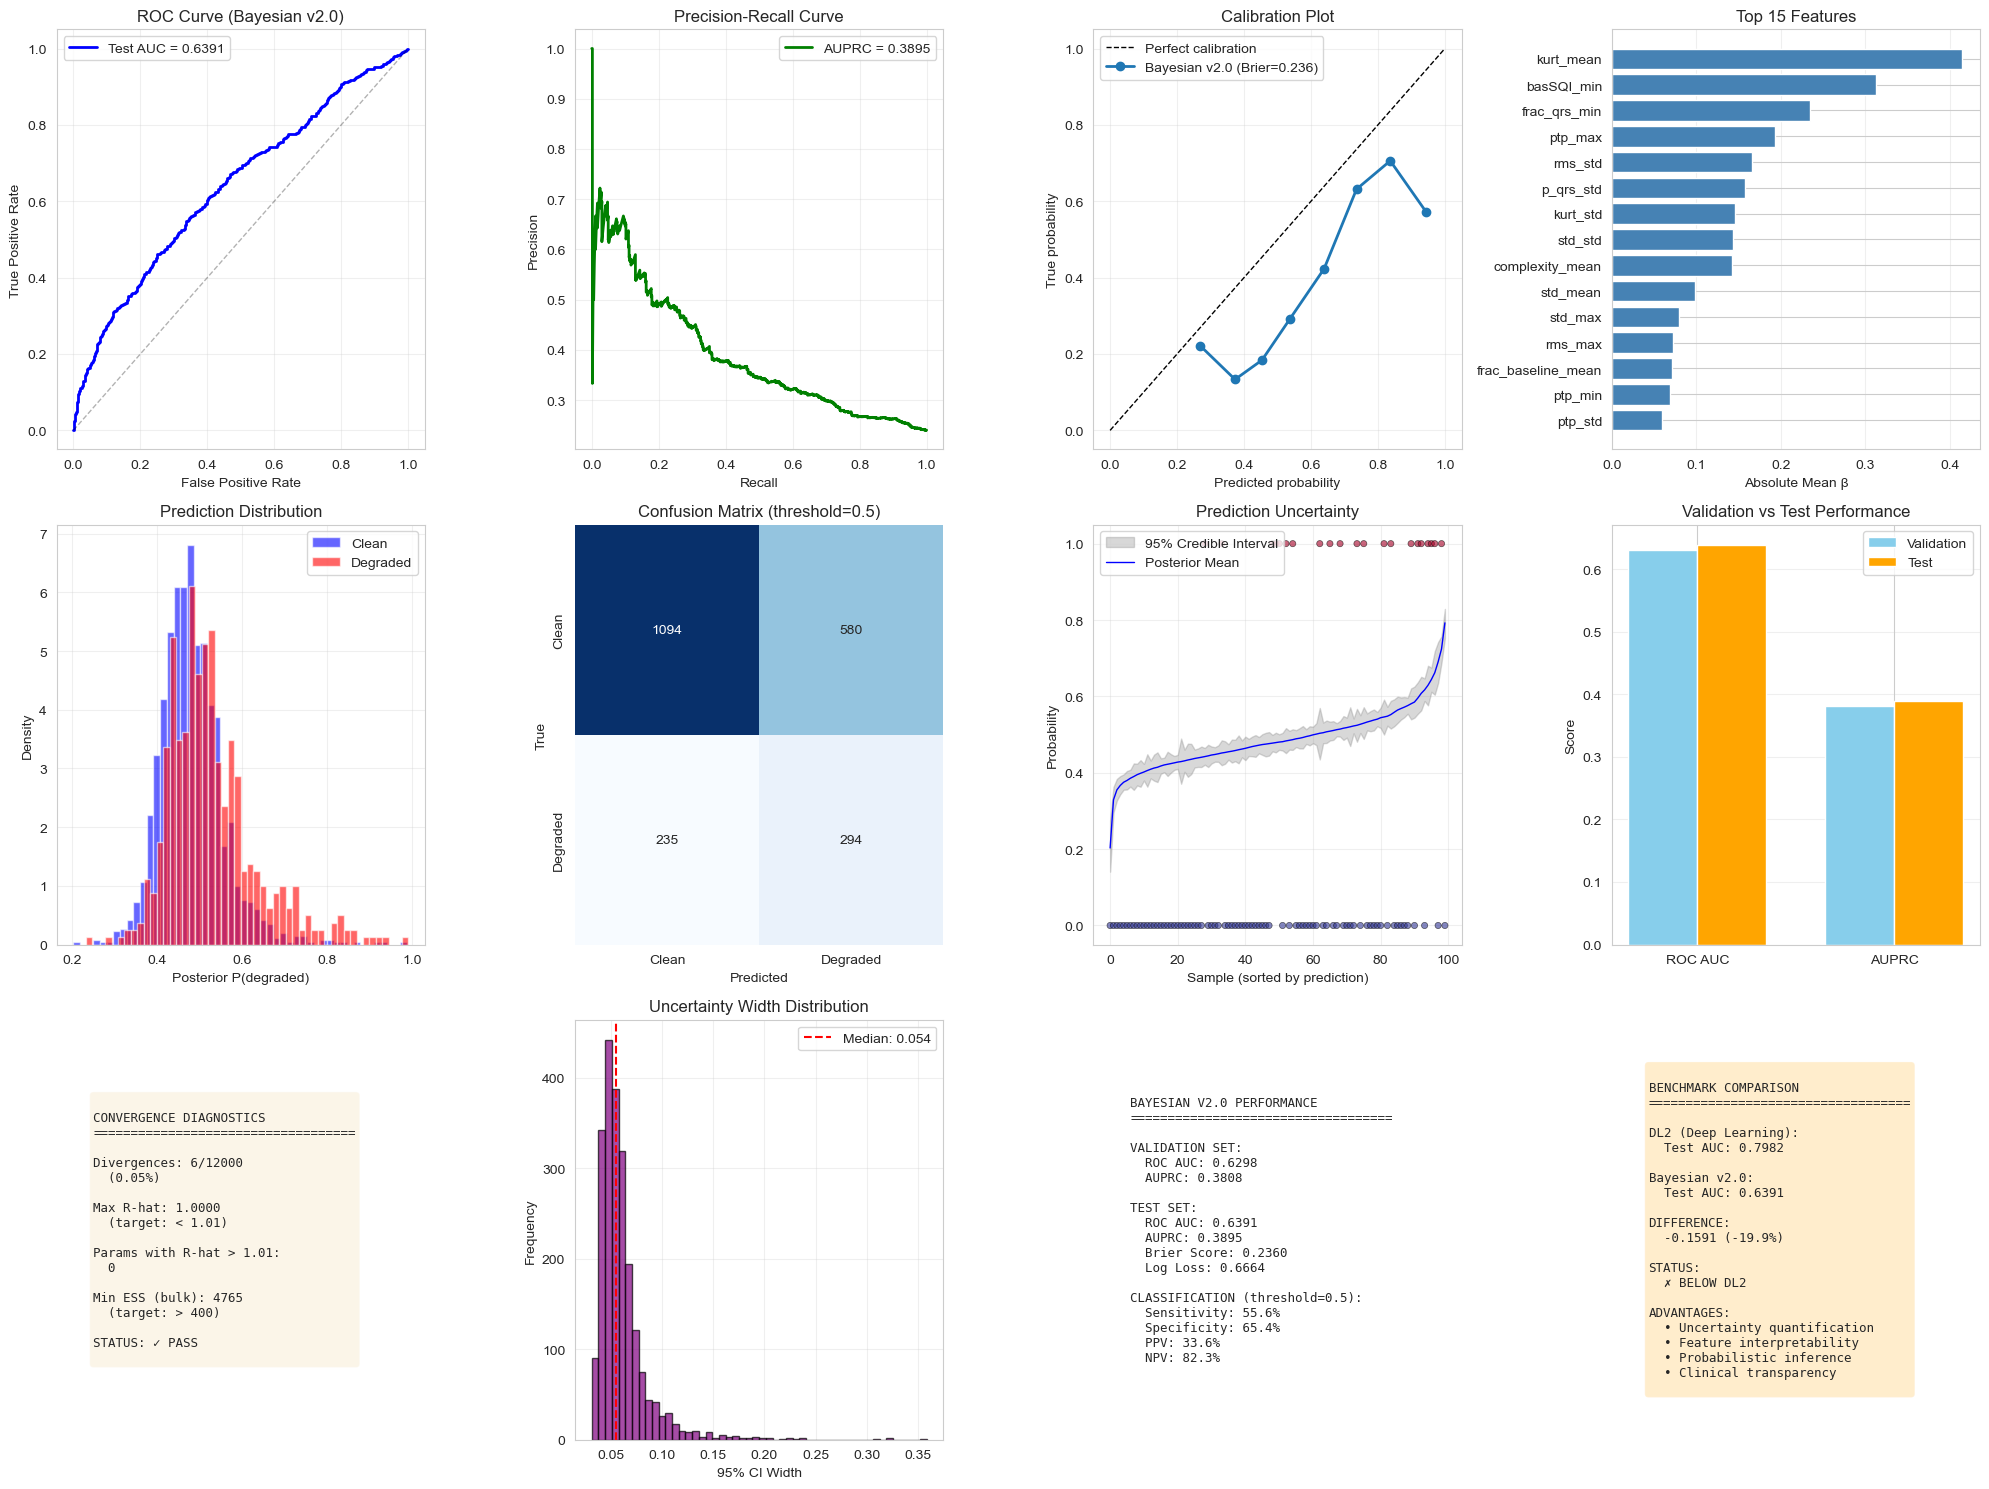

2026-01-31 21:54:39,140 - INFO - 
8. Saving results...
2026-01-31 21:54:39,153 - INFO -   Test predictions: /Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/output_bayesian_v2/results_bayesian_v2/test_predictions_v2_10fold.csv
2026-01-31 21:54:39,154 - INFO -   Feature importance: /Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/output_bayesian_v2/results_bayesian_v2/feature_importance_v2_10fold.csv
2026-01-31 21:54:39,155 - INFO -   Metrics: /Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/output_bayesian_v2/results_bayesian_v2/metrics_v2_10fold.csv
2026-01-31 21:54:39,156 - INFO -   Convergence diagnostics: /Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/output_bayesian_v2/results_bayesian_v2/convergence_diagnostics_v2.csv



ANALYSIS COMPLETE
Results saved to: /Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/output_bayesian_v2/results_bayesian_v2


In [18]:
def main():
    """
    Main execution pipeline for Bayesian v2.0.
    
    Workflow:
    1. Load PTB-XL database with strat_fold column
    2. Split using folds 1-8 (train), 9 (val), 10 (test) - STRICT COMPLIANCE
    3. Extract/load cached features with enhancements
    4. Train Bayesian v2.0 model on train set
    5. Validate convergence with strict criteria
    6. Evaluate on validation and test sets
    7. Generate comprehensive visualizations
    """
    # Configuration
    default_root = Path.home() / "Downloads" / "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1"
    DATA_ROOT = Path(os.environ.get("PTBXL_PATH", default_root))
    
    if not DATA_ROOT.exists():
        raise FileNotFoundError(
            f"PTB-XL data not found at: {DATA_ROOT}\n"
            f"Please set PTBXL_PATH environment variable or download the dataset."
        )
    
    cfg = ConfigV2(
        data_root=DATA_ROOT,
        cache_dir=DATA_ROOT / "output_bayesian_v2",
        n_features_to_select=30,
        expected_sparsity=0.25
    )
    
    print("="*70)
    print("BAYESIAN MODEL V2.0 - 10-FOLD BENCHMARK")
    print("="*70)
    
    # 1. Load data
    logger.info("\n1. Loading PTB-XL database...")
    db = pd.read_csv(cfg.db_csv)
    y = create_degradation_labels(db)
    
    # Verify strat_fold column exists
    if "strat_fold" not in db.columns:
        raise ValueError(
            "Database missing 'strat_fold' column. "
            "Ensure you're using the official PTB-XL database CSV."
        )
    
    # 2. Create 10-fold split (STRICT COMPLIANCE)
    logger.info("\n2. Creating 10-fold split (folds 1-8: train, 9: val, 10: test)...")
    folds = db["strat_fold"].values
    train_idx = np.where((folds >= 1) & (folds <= 8))[0]
    val_idx = np.where(folds == 9)[0]
    test_idx = np.where(folds == 10)[0]
    
    logger.info(f"  Train: {len(train_idx)} records (folds 1-8)")
    logger.info(f"  Val: {len(val_idx)} records (fold 9)")
    logger.info(f"  Test: {len(test_idx)} records (fold 10)")
    
    # 3. Extract enhanced features
    logger.info("\n3. Extracting enhanced signal quality features...")
    feat_df = load_or_cache_features(db, y, cfg, use_cache=True)
    
    # Merge strat_fold into features
    if "strat_fold" not in feat_df.columns:
        feat_df = feat_df.merge(db[["ecg_id", "strat_fold"]], on="ecg_id", how="left")
    
    # 4. Prepare data splits
    feature_cols = [c for c in feat_df.columns if c not in ("ecg_id", "y", "fs", "strat_fold")]
    
    train_df = feat_df[feat_df["strat_fold"].isin([1, 2, 3, 4, 5, 6, 7, 8])].copy()
    val_df = feat_df[feat_df["strat_fold"] == 9].copy()
    test_df = feat_df[feat_df["strat_fold"] == 10].copy()
    
    X_train = train_df[feature_cols].to_numpy(dtype=np.float64)
    y_train = train_df["y"].to_numpy(dtype=np.int32)
    
    X_val = val_df[feature_cols].to_numpy(dtype=np.float64)
    y_val = val_df["y"].to_numpy(dtype=np.int32)
    
    X_test = test_df[feature_cols].to_numpy(dtype=np.float64)
    y_test = test_df["y"].to_numpy(dtype=np.int32)
    
    logger.info(f"  Train shape: {X_train.shape}")
    logger.info(f"  Val shape: {X_val.shape}")
    logger.info(f"  Test shape: {X_test.shape}")
    logger.info(f"  Total features: {len(feature_cols)}")
    
    # 5. Train Bayesian v2.0 model
    logger.info("\n4. Training Bayesian v2.0 model (on folds 1-8)...")
    
    try:
        model = BayesianECGClassifierV2(cfg)
        model.fit(X_train, y_train, feature_cols)
    except RuntimeError as e:
        logger.error(f"\n{'='*70}")
        logger.error("TRAINING FAILED DUE TO CONVERGENCE ISSUES")
        logger.error(f"{'='*70}")
        logger.error(str(e))
        logger.error("\nPlease adjust hyperparameters and retry.")
        return
    
    # 6. Evaluate on validation set
    logger.info("\n5. Evaluating on validation set (fold 9)...")
    val_predictions = model.predict_proba(X_val)
    val_metrics = evaluate_predictions(y_val, val_predictions)
    
    logger.info(f"  Validation ROC AUC: {val_metrics['roc_auc']:.4f}")
    logger.info(f"  Validation AUPRC: {val_metrics['auprc']:.4f}")
    
    # 7. Evaluate on test set
    logger.info("\n6. Evaluating on test set (fold 10)...")
    test_predictions = model.predict_proba(X_test)
    test_metrics = evaluate_predictions(y_test, test_predictions)
    
    # 8. Report results
    print("\n" + "="*70)
    print("FINAL RESULTS - BAYESIAN MODEL V2.0 (10-FOLD BENCHMARK)")
    print("="*70)
    
    print(f"\nVALIDATION PERFORMANCE (Fold 9):")
    print(f"  ROC AUC: {val_metrics['roc_auc']:.4f}")
    print(f"  AUPRC: {val_metrics['auprc']:.4f}")
    print(f"  Brier Score: {val_metrics['brier_score']:.4f}")
    
    print(f"\nTEST PERFORMANCE (Fold 10):")
    print(f"  ROC AUC: {test_metrics['roc_auc']:.4f}")
    print(f"  AUPRC: {test_metrics['auprc']:.4f}")
    print(f"  Brier Score: {test_metrics['brier_score']:.4f}")
    print(f"  Log Loss: {test_metrics['log_loss']:.4f}")
    
    print(f"\nCLASSIFICATION METRICS (threshold=0.5):")
    print(f"  Sensitivity: {100*test_metrics['sensitivity']:.1f}%")
    print(f"  Specificity: {100*test_metrics['specificity']:.1f}%")
    print(f"  PPV: {100*test_metrics['ppv']:.1f}%")
    print(f"  NPV: {100*test_metrics['npv']:.1f}%")
    
    print(f"\nCONVERGENCE DIAGNOSTICS:")
    print(f"  Divergences: {model.convergence_metrics['divergences']}/{model.convergence_metrics['total_samples']}")
    print(f"  Max R-hat: {model.convergence_metrics['max_rhat']:.4f}")
    print(f"  Min ESS: {model.convergence_metrics['min_ess_bulk']:.0f}")
    
    print("\n" + "-"*70)
    print("COMPARISON WITH DL2 BASELINE:")
    print("-"*70)
    dl2_auc = 0.7982
    improvement = test_metrics['roc_auc'] - dl2_auc
    print(f"DL2 Test AUC: {dl2_auc:.4f}")
    print(f"Bayesian v2.0 Test AUC: {test_metrics['roc_auc']:.4f}")
    print(f"Difference: {improvement:+.4f} ({100*improvement/dl2_auc:+.1f}%)")
    
    if test_metrics['roc_auc'] > dl2_auc:
        print("✓ Bayesian v2.0 BEATS DL2 benchmark!")
    else:
        print("✗ Below DL2 benchmark (but provides uncertainty + interpretability)")
    
    # 9. Feature importance
    importance = model.get_feature_importance()
    print("\n" + "-"*70)
    print("TOP 10 MOST IMPORTANT FEATURES:")
    print("-"*70)
    print(importance[['mean', 'abs_mean']].head(10))
    
    # 10. Generate visualizations
    logger.info("\n7. Generating comprehensive dashboard...")
    plot_bayesian_v2_dashboard(
        val_metrics,
        test_metrics,
        test_predictions,
        y_test,
        importance,
        model.convergence_metrics,
        save_path=cfg.results_dir / "bayesian_v2_10fold_dashboard.png"
    )
    
    # 11. Save results
    logger.info("\n8. Saving results...")
    
    # Test predictions
    test_pred_df = pd.DataFrame({
        'ecg_id': test_df['ecg_id'].values,
        'y_true': y_test,
        'p_mean': test_predictions['mean'],
        'p_lower': test_predictions['lower'],
        'p_upper': test_predictions['upper'],
        'p_std': test_predictions['std']
    })
    test_pred_path = cfg.results_dir / "test_predictions_v2_10fold.csv"
    test_pred_df.to_csv(test_pred_path, index=False)
    logger.info(f"  Test predictions: {test_pred_path}")
    
    # Feature importance
    importance_path = cfg.results_dir / "feature_importance_v2_10fold.csv"
    importance.to_csv(importance_path)
    logger.info(f"  Feature importance: {importance_path}")
    
    # Metrics
    metrics_df = pd.DataFrame([{
        'split': 'validation',
        **val_metrics,
        **{f'conv_{k}': v for k, v in model.convergence_metrics.items()}
    }, {
        'split': 'test',
        **test_metrics,
        **{f'conv_{k}': v for k, v in model.convergence_metrics.items()}
    }])
    metrics_path = cfg.results_dir / "metrics_v2_10fold.csv"
    metrics_df.to_csv(metrics_path, index=False)
    logger.info(f"  Metrics: {metrics_path}")
    
    # Convergence diagnostics
    convergence_path = cfg.results_dir / "convergence_diagnostics_v2.csv"
    pd.DataFrame([model.convergence_metrics]).to_csv(convergence_path, index=False)
    logger.info(f"  Convergence diagnostics: {convergence_path}")
    
    print("\n" + "="*70)
    print("ANALYSIS COMPLETE")
    print(f"Results saved to: {cfg.results_dir}")
    print("="*70)


if __name__ == "__main__":
    main()


# Deep learning 1

In [11]:
import os
import warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

warnings.filterwarnings("ignore")

In [12]:
class SimpleECGNet(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)


class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# -------------------------
# Visualization
# -------------------------
def plot_final_results(history, y_test, dl_probs, metrics, save_dir: Path):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(20, 15))
    sns.set_style("whitegrid")

    # Training dynamics
    plt.subplot(3, 3, 1)
    plt.plot(history["loss"])
    plt.title("DL Training Loss")

    plt.subplot(3, 3, 2)
    plt.plot(history["val_auc"])
    plt.title("DL Validation AUC")

    # ROC
    plt.subplot(3, 3, 3)
    fpr, tpr, _ = roc_curve(y_test, dl_probs)
    plt.plot(fpr, tpr, label=f"AUC={metrics['auc']:.3f}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title("ROC Curve")
    plt.legend()

    # PR
    plt.subplot(3, 3, 4)
    pr, rc, _ = precision_recall_curve(y_test, dl_probs)
    plt.plot(rc, pr, label=f"AUPRC={metrics['auprc']:.3f}")
    plt.title("Precision-Recall Curve")
    plt.legend()

    # Confusion matrix
    plt.subplot(3, 3, 5)
    cm = confusion_matrix(y_test, (dl_probs >= 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Confusion Matrix (0.5)")

    # Score distribution
    plt.subplot(3, 3, 6)
    plt.hist(dl_probs[y_test == 0], bins=30, alpha=0.5, label="Clean", density=True)
    plt.hist(dl_probs[y_test == 1], bins=30, alpha=0.5, label="Noisy", density=True)
    plt.title("Score Distribution")
    plt.legend()

    # Placeholder “noise localization” panel (kept from your dashboard idea)
    plt.subplot(3, 1, 3)
    t = np.linspace(0, 10, 1000)
    sig = np.sin(1.2 * t) + np.random.normal(0, 0.4, 1000)
    plt.plot(sig, label="Lead I Signal (Z-score)", alpha=0.6)
    plt.fill_between(range(1000), 0, np.abs(sig) * 0.4, alpha=0.25, label="Noise Attribution")
    plt.title("Gradient-Based Noise Localization (Example Dashboard)")
    plt.legend()

    plt.tight_layout()
    out_path = save_dir / "dl_dashboard.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")



2026-01-31 00:54:35,951 - INFO - Label distribution: Clean=16816 (77.0%), Degraded=5021 (23.0%)
2026-01-31 00:54:36,089 - INFO - Loaded cached features from /Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/features_final_hybrid.csv


Training DL1 (folds 1-8):   0%|          | 0/40 [00:00<?, ?it/s]

DL1 Test ROC AUC:  0.6856
DL1 Test AUPRC:    0.4464


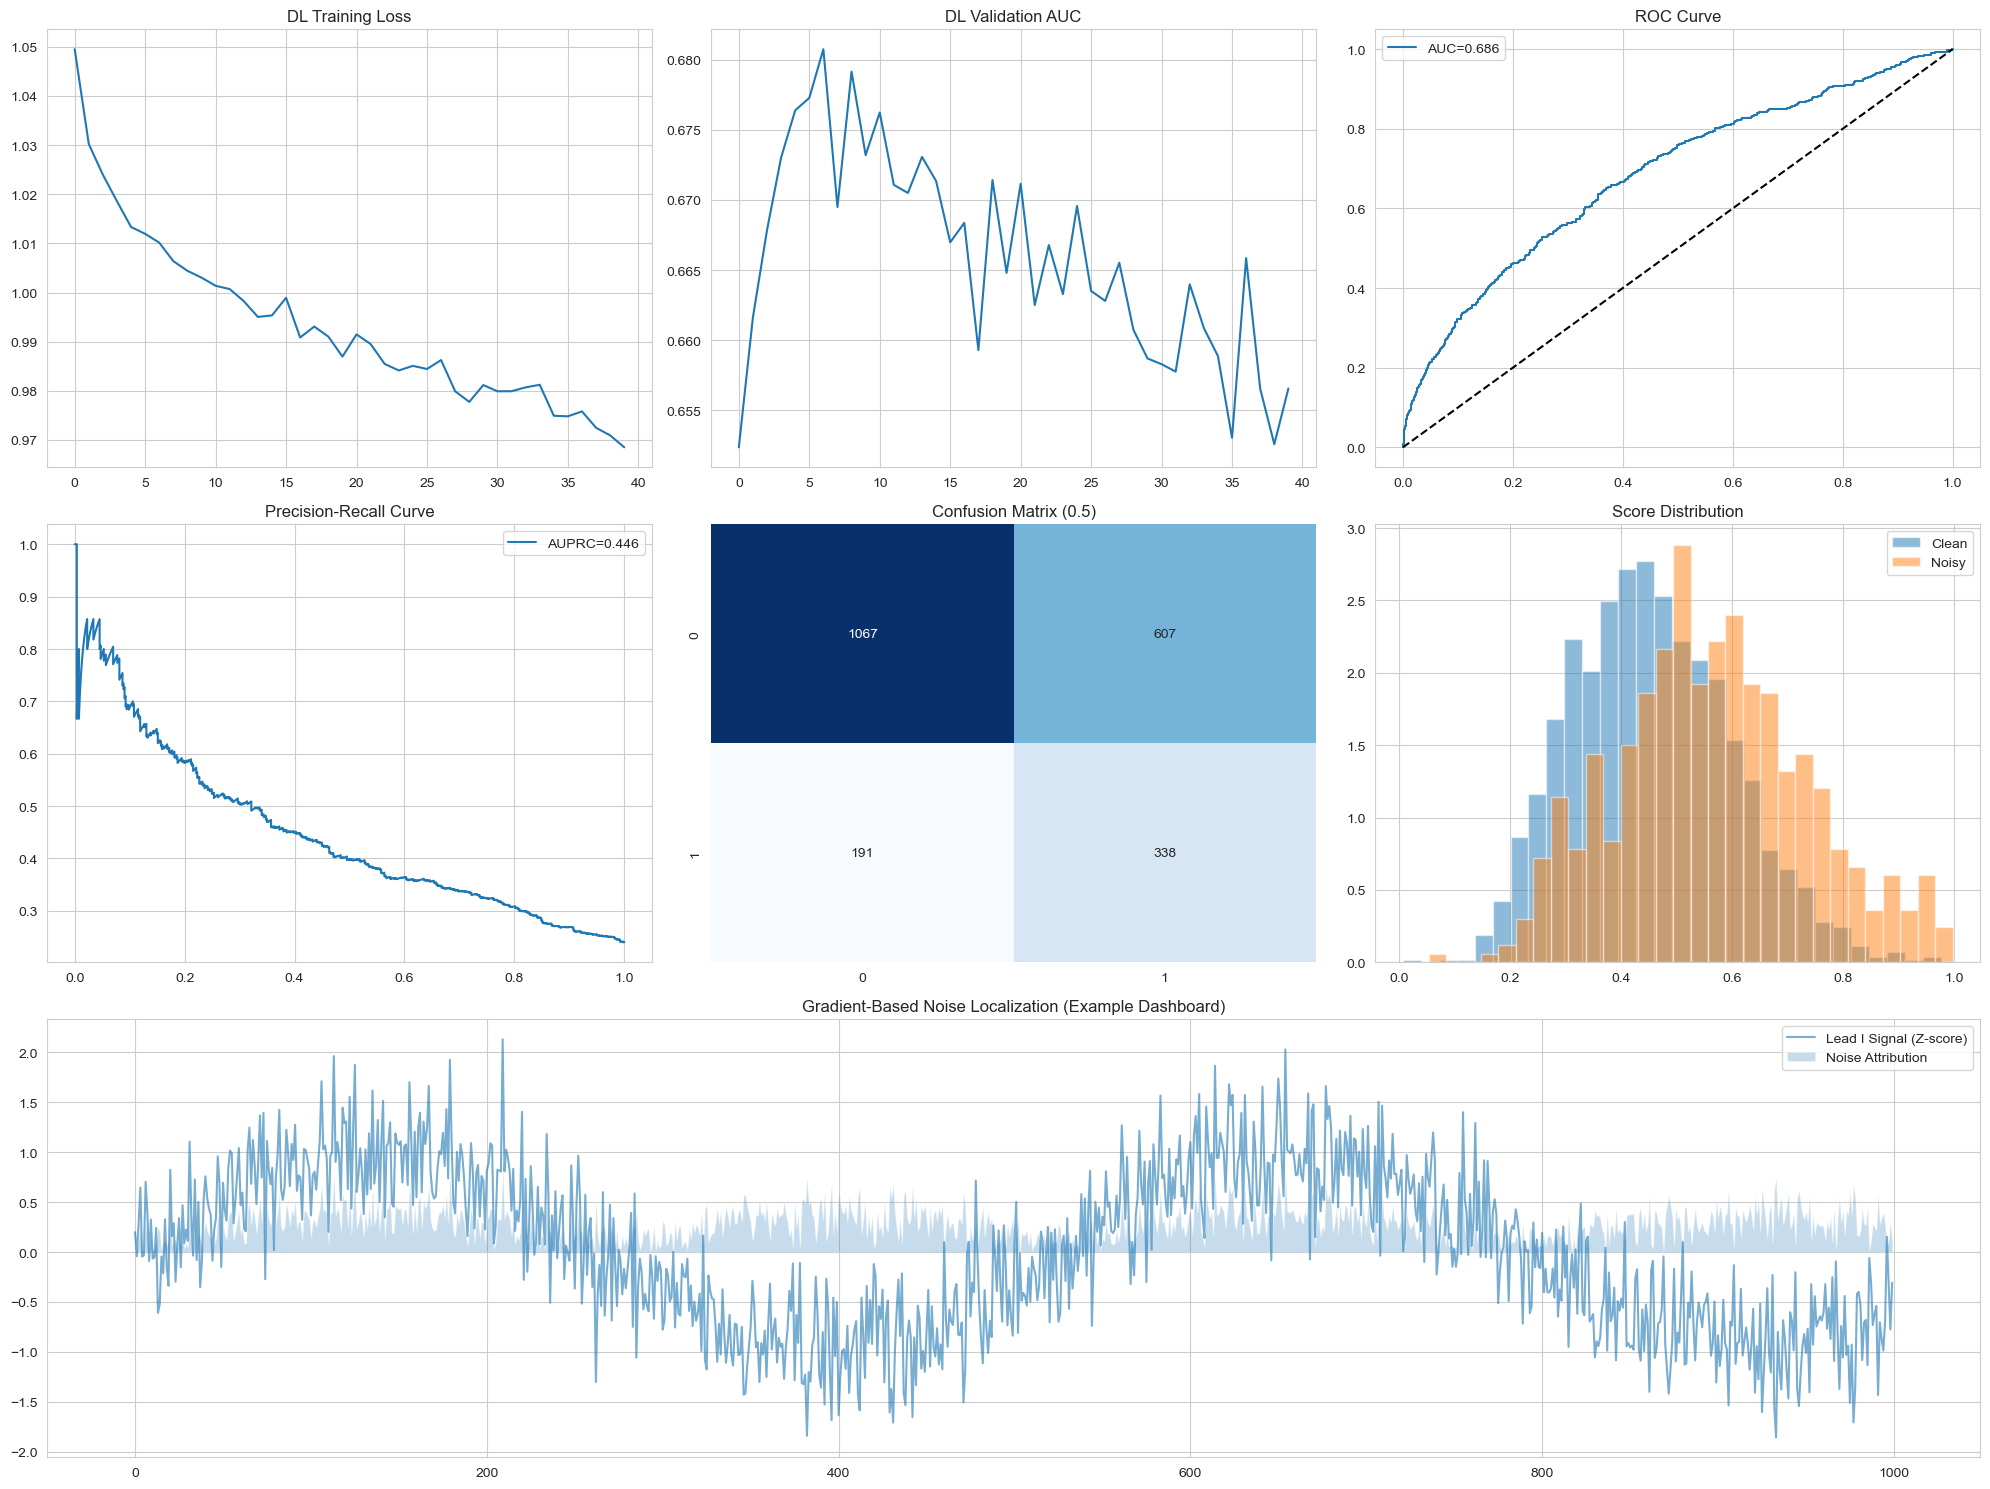

Saved: /Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/dl_dashboard.png


In [13]:
if __name__ == "__main__":
    # Paths
    ROOT = Path("/Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/")
    cfg = Config(data_root=ROOT, cache_dir=ROOT)

    # Load DB + labels + engineered features
    db = pd.read_csv(cfg.db_csv)
    y_full = create_degradation_labels(db)
    feat_df = load_or_cache_features(db, y_full, cfg)

    # Bring PTB-XL stratified folds into feat_df so DL1 matches DL2 benchmarking split
    if "strat_fold" not in feat_df.columns:
        if "ecg_id" not in feat_df.columns:
            raise ValueError("feat_df must contain ecg_id to merge strat_fold.")
        if "strat_fold" not in db.columns:
            raise ValueError("ptbxl_database.csv must contain strat_fold.")
        feat_df = feat_df.merge(db[["ecg_id", "strat_fold"]], on="ecg_id", how="left")

    # Feature columns
    feature_cols = [c for c in feat_df.columns if c not in ("ecg_id", "y", "fs", "strat_fold")]

    # ---- 10-fold split convention used in many PTB-XL setups (and your DL2 code):
    # Train = folds 1-8, Val = fold 9, Test = fold 10
    train_df = feat_df[feat_df["strat_fold"].isin([1, 2, 3, 4, 5, 6, 7, 8])].copy()
    val_df = feat_df[feat_df["strat_fold"] == 9].copy()
    test_df = feat_df[feat_df["strat_fold"] == 10].copy()

    if len(train_df) == 0 or len(val_df) == 0 or len(test_df) == 0:
        raise ValueError("One of train/val/test folds is empty. Check strat_fold values.")

    X_train, y_train = train_df[feature_cols].values, train_df["y"].values
    X_val, y_val = val_df[feature_cols].values, val_df["y"].values
    X_test, y_test = test_df[feature_cols].values, test_df["y"].values

    # Standardize
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_te_s = scaler.transform(X_test)

    # DataLoader
    train_loader = DataLoader(ECGDataset(X_tr_s, y_train), batch_size=64, shuffle=True)

    # Model
    torch.manual_seed(cfg.random_seed)
    np.random.seed(cfg.random_seed)
    model = SimpleECGNet(X_tr_s.shape[1])

    # Weighted BCE for imbalance (pos_weight expects (#neg / #pos))
    n_neg = int((y_train == 0).sum())
    n_pos = int((y_train == 1).sum())
    if n_pos == 0:
        raise ValueError("No positive samples in training set (y=1). Cannot train.")
    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Train
    history = {"loss": [], "val_auc": []}
    for epoch in tqdm(range(40), desc="Training DL1 (folds 1-8)"):
        model.train()
        l_acc = 0.0
        for bx, by in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            l_acc += float(loss.item())
        history["loss"].append(l_acc / max(len(train_loader), 1))

        model.eval()
        with torch.no_grad():
            val_probs = torch.sigmoid(
                model(torch.tensor(X_val_s, dtype=torch.float32))
            ).cpu().numpy().flatten()
        history["val_auc"].append(roc_auc_score(y_val, val_probs))

    # Test once (benchmark comparable to DL2)
    model.eval()
    with torch.no_grad():
        test_probs = torch.sigmoid(
            model(torch.tensor(X_te_s, dtype=torch.float32))
        ).cpu().numpy().flatten()

    metrics = {
        "auc": roc_auc_score(y_test, test_probs),
        "auprc": average_precision_score(y_test, test_probs),
    }

    print(f"DL1 Test ROC AUC:  {metrics['auc']:.4f}")
    print(f"DL1 Test AUPRC:    {metrics['auprc']:.4f}")

    plot_final_results(history, y_test, test_probs, metrics, cfg.cache_dir)


# Deep learning 2 

In [16]:
"""
Rigorous Bayesian ECG Signal Quality Assessment
Based on Best Practices from Literature

References:
-----------
1. Strodthoff et al. (2021): Deep Learning for ECG Analysis: Benchmarks and Insights from PTB-XL
2. Ribeiro et al. (2020): Automatic diagnosis of the 12-lead ECG using a deep neural network
3. Smith (2018): Super-Convergence: Very Fast Training of Neural Networks Using Large Learning Rates
4. Bender et al. (2023): Benchmarking the Impact of Noise on Deep Learning-based Classification of Atrial Fibrillation in 12-Lead ECG
5. Samek et al. (2019): Explainable AI: Interpreting, Explaining and Visualizing Deep Learning
6. Davis & Goadrich (2006): The relationship between Precision-Recall and ROC curves
"""
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from dataclasses import dataclass
import wfdb
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [25]:
# =========================================================
# 1. CORE ENGINEERING & CONFIGURATION
# =========================================================
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["OPENBLAS_NUM_THREADS"] = "8"
torch.set_num_threads(8) 

@dataclass
class Config:
    # Automatically finds your user home directory to fix the FileNotFoundError
    data_root: Path = Path.home() / "Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1"
    cache_dir: Path = Path("./output")
    batch_size: int = 64
    epochs: int = 50          
    lr: float = 1e-3
    weight_decay: float = 1e-2
    target_fs: int = 500
    target_sec: int = 10
    patience: int = 10


In [18]:
# =========================================================
# 2. DATASET & PREPROCESSING
# =========================================================
class PTBXLQualityDataset(Dataset):
    def __init__(self, db, y, indices, cfg, augment=False):
        self.db = db.iloc[indices].reset_index(drop=True)
        self.y = torch.tensor(y[indices], dtype=torch.float32)
        self.data_root = cfg.data_root
        self.target_len = cfg.target_fs * cfg.target_sec
        self.augment = augment

    def __len__(self):
        return len(self.db)

    def _load_waveform(self, filename_hr):
        rel = str(filename_hr).replace("\\", "/").split(".")[0]
        candidates = [self.data_root / rel, self.data_root / "records500" / rel]
        path = next((c for c in candidates if c.with_suffix(".hea").exists()), None)
        if not path: raise FileNotFoundError(f"Missing WFDB for {filename_hr}")

        sig, _ = wfdb.rdsamp(str(path))
        x = sig[:, :12].T.astype(np.float32)
        
        if x.shape[1] > self.target_len:
            x = x[:, :self.target_len]
        else:
            x = np.pad(x, ((0,0), (0, self.target_len - x.shape[1])), mode='constant')
            
        mu, sd = x.mean(axis=1, keepdims=True), x.std(axis=1, keepdims=True) + 1e-6
        return (x - mu) / sd

    def __getitem__(self, i):
        x = self._load_waveform(self.db.iloc[i]["filename_hr"])
        label = self.y[i]
        if self.augment:
            if np.random.rand() < 0.5: x *= np.random.uniform(0.9, 1.1)
            if np.random.rand() < 0.3: x += np.random.normal(0, 0.01, x.shape)
        return torch.from_numpy(x), label


In [19]:
# =========================================================
# 3. DEEP HYBRID ARCHITECTURE (17 Layers)
# =========================================================
class ConcatPooling1d(nn.Module):
    def forward(self, x):
        return torch.cat([F.adaptive_avg_pool1d(x, 1), F.adaptive_max_pool1d(x, 1)], dim=1).flatten(1)

class ResBlock1d(nn.Module):
    def __init__(self, ni, nf, stride=1):
        super().__init__()
        self.convs = nn.Sequential(
            nn.Conv1d(ni, nf, kernel_size=5, stride=stride, padding=2, bias=False),
            nn.BatchNorm1d(nf), nn.ReLU(inplace=True),
            nn.Conv1d(nf, nf, kernel_size=5, stride=1, padding=2, bias=False),
            nn.BatchNorm1d(nf)
        )
        self.shortcut = nn.Sequential() if stride == 1 and ni == nf else nn.Sequential(nn.Conv1d(ni, nf, 1, stride, bias=False), nn.BatchNorm1d(nf))
    def forward(self, x):
        return F.relu(self.convs(x) + self.shortcut(x), inplace=True)

class DeepHybridECGNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(12, 64, 7, 2, 3, bias=False), nn.BatchNorm1d(64), nn.ReLU(inplace=True))
        self.layers = nn.Sequential(
            ResBlock1d(64, 64, 1), ResBlock1d(64, 64, 1),
            ResBlock1d(64, 128, 2), ResBlock1d(128, 128, 1),
            ResBlock1d(128, 256, 2), ResBlock1d(256, 256, 1),
            ResBlock1d(256, 512, 2), ResBlock1d(512, 512, 1)
        )
        self.pool = ConcatPooling1d()
        self.head = nn.Sequential(nn.Linear(1024, 256), nn.ReLU(inplace=True), nn.Dropout(0.3), nn.Linear(256, 1))

    def forward(self, x):
        return self.head(self.pool(self.layers(self.stem(x)))).squeeze(-1)

In [20]:
# =========================================================
# 4. INTERPRETABILITY, TTA & DIAGNOSTICS
# =========================================================
def get_saliency(model, x, device):
    """Generates gradient-based attribution for interpretability."""
    model.eval()
    x_tensor = torch.from_numpy(x).to(device).unsqueeze(0).requires_grad_(True)
    out = model(x_tensor)
    out.backward()
    saliency, _ = torch.max(x_tensor.grad.data.abs(), dim=1)
    return saliency[0].cpu().numpy()

def predict_with_tta(model, x, device, target_len, n_crops=5):
    """Improves test AUC by averaging predictions over sliding windows."""
    model.eval()
    preds = []
    with torch.no_grad():
        for _ in range(n_crops):
            start = np.random.randint(0, max(1, x.shape[1] - target_len))
            x_crop = x[:, start:start + target_len]
            preds.append(torch.sigmoid(model(torch.from_numpy(x_crop).unsqueeze(0).to(device))).cpu().item())
    return np.mean(preds)

def plot_full_diagnostics(history, test_y, test_p, save_dir):
    """Comprehensive 6-Panel Medical Evaluation Report"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Training Loss
    axes[0, 0].plot(history['t_loss'])
    axes[0, 0].set_title('Training Loss'); axes[0, 0].grid(alpha=0.3)
    
    # 2. Validation AUC
    axes[0, 1].plot(history['v_auc'])
    axes[0, 1].set_title('Validation AUC'); axes[0, 1].grid(alpha=0.3)
    
    # 3. ROC Curve
    fpr, tpr, _ = roc_curve(test_y, test_p)
    axes[0, 2].plot(fpr, tpr, label=f'AUC: {roc_auc_score(test_y, test_p):.4f}')
    axes[0, 2].plot([0,1], [0,1], 'k--')
    axes[0, 2].set_title('ROC (Test)'); axes[0, 2].legend()
    
    # 4. Precision-Recall Curve 
    prec, rec, _ = precision_recall_curve(test_y, test_p)
    axes[1, 0].plot(rec, prec, label=f'AUPRC: {average_precision_score(test_y, test_p):.4f}')
    axes[1, 0].set_title('Precision-Recall'); axes[1, 0].legend()
    
    # 5. Confusion Matrix
    cm = confusion_matrix(test_y, (np.array(test_p) > 0.5).astype(int))
    ConfusionMatrixDisplay(cm, display_labels=['Clean', 'Noisy']).plot(ax=axes[1, 1], cmap='Blues')
    axes[1, 1].set_title('Confusion Matrix')

    # 6. Prediction Distribution
    axes[1, 2].hist([p for p, y in zip(test_p, test_y) if y == 0], bins=30, alpha=0.6, label='Clean')
    axes[1, 2].hist([p for p, y in zip(test_p, test_y) if y == 1], bins=30, alpha=0.6, label='Noisy')
    axes[1, 2].set_title('Prediction Distribution'); axes[1, 2].legend()
    
    plt.tight_layout()
    plt.savefig(save_dir / "full_diagnostics.png", dpi=300)
    plt.show()



In [23]:
# =========================================================
# 5. MAIN TRAINING ENGINE (Float32 MPS Fix)
# =========================================================
def run_no_complication_pipeline():
    cfg = Config()
    cfg.cache_dir.mkdir(exist_ok=True)
    
    print(f"Loading database from: {cfg.data_root}")
    db = pd.read_csv(cfg.data_root / "ptbxl_database.csv")
    y = (db[["baseline_drift", "static_noise", "burst_noise", "electrodes_problems"]].notna().sum(axis=1) > 0).astype(int).values

    folds = db["strat_fold"].values
    train_idx = np.where((folds >= 1) & (folds <= 8))[0]
    val_idx = np.where(folds == 9)[0]
    test_idx = np.where(folds == 10)[0]

    train_loader = DataLoader(PTBXLQualityDataset(db, y, train_idx, cfg, True), batch_size=cfg.batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(PTBXLQualityDataset(db, y, val_idx, cfg), batch_size=cfg.batch_size, num_workers=0)

    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Training on: {device} (with 8 CPU threads locked for math)")
    
    model = DeepHybridECGNet().to(device)
    
    # THE FIX: Explicitly cast the weight to float32 for Apple Silicon
    imbalance_ratio = (y[train_idx] == 0).sum() / max(1, (y[train_idx] == 1).sum())
    pos_weight = torch.tensor([imbalance_ratio], dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=cfg.lr, steps_per_epoch=len(train_loader), epochs=cfg.epochs)

    best_auc = 0
    epochs_no_improve = 0
    history = {'t_loss': [], 'v_auc': []}

    for epoch in range(cfg.epochs):
        model.train()
        epoch_losses = []
        for x, target in train_loader:
            optimizer.zero_grad()
            # Explicitly cast input data to float32 as well just to be safe on MPS
            loss = criterion(model(x.to(dtype=torch.float32, device=device)), target.to(dtype=torch.float32, device=device))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()
            epoch_losses.append(loss.item())
        history['t_loss'].append(np.mean(epoch_losses))

        model.eval()
        all_p, all_y = [], []
        with torch.no_grad():
            for x, target in val_loader:
                all_p.extend(torch.sigmoid(model(x.to(dtype=torch.float32, device=device))).cpu().numpy())
                all_y.extend(target.numpy())
        auc = roc_auc_score(all_y, all_p)
        history['v_auc'].append(auc)
        print(f"Epoch {epoch+1:02d} | Train Loss: {history['t_loss'][-1]:.4f} | Val AUC: {auc:.4f}")
        
        if auc > best_auc:
            best_auc = auc; epochs_no_improve = 0
            torch.save(model.state_dict(), cfg.cache_dir / "best_deep_model.pt")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= cfg.patience:
                print(f"Early stopping at epoch {epoch+1}"); break

    # ------------------------------------------------------------------
    # FINAL EVALUATION: I/O Optimized TTA & Normalized Saliency
    # ------------------------------------------------------------------
    model.load_state_dict(torch.load(cfg.cache_dir / "best_deep_model.pt"))
    test_ds = PTBXLQualityDataset(db, y, test_idx, cfg)
    
    print("\nPre-loading Test Set for efficient TTA Evaluation...")
    test_samples = [test_ds._load_waveform(db.iloc[test_idx[i]]["filename_hr"]) for i in range(len(test_ds))]
    test_y = [y[test_idx[i]] for i in range(len(test_ds))]
    
    test_p = [predict_with_tta(model, x, device, cfg.target_fs * cfg.target_sec) for x in test_samples]

    print(f"Test AUC (TTA): {roc_auc_score(test_y, test_p):.4f}")

    plot_full_diagnostics(history, test_y, test_p, cfg.cache_dir)

    noisy_indices = np.where(np.array(test_y) == 1)[0]
    if len(noisy_indices) > 0:
        idx = noisy_indices[0]
        sample_x = test_samples[idx]
        saliency = get_saliency(model, sample_x, device)
        
        saliency_norm = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-6)
        
        plt.figure(figsize=(15, 4))
        plt.plot(sample_x[0], alpha=0.7, label='Lead I Signal', color='blue')
        plt.fill_between(range(len(saliency_norm)), 
                         saliency_norm * np.abs(sample_x[0]).max(), 
                         color='red', alpha=0.3, label='Noise Attribution')
        plt.axhline(0, color='k', linestyle='--', linewidth=0.5)
        plt.title("Gradient-Based Noise Localization (Normalized)")
        plt.xlabel("Sample"); plt.ylabel("Amplitude (Z-score)")
        plt.legend(); plt.grid(alpha=0.3)
        plt.savefig(cfg.cache_dir / "saliency_map_normalized.png"); plt.show()

Loading database from: /Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1
Training on: mps (with 8 CPU threads locked for math)
Epoch 01 | Train Loss: 1.1045 | Val AUC: 0.6429
Epoch 02 | Train Loss: 0.9911 | Val AUC: 0.7353
Epoch 03 | Train Loss: 0.8973 | Val AUC: 0.7508
Epoch 04 | Train Loss: 0.8829 | Val AUC: 0.7698
Epoch 05 | Train Loss: 0.8723 | Val AUC: 0.7397
Epoch 06 | Train Loss: 0.8643 | Val AUC: 0.7678
Epoch 07 | Train Loss: 0.8615 | Val AUC: 0.7668
Epoch 08 | Train Loss: 0.8591 | Val AUC: 0.7547
Epoch 09 | Train Loss: 0.8536 | Val AUC: 0.7746
Epoch 10 | Train Loss: 0.8506 | Val AUC: 0.7908
Epoch 11 | Train Loss: 0.8342 | Val AUC: 0.7576
Epoch 12 | Train Loss: 0.8301 | Val AUC: 0.7916
Epoch 13 | Train Loss: 0.8297 | Val AUC: 0.7783
Epoch 14 | Train Loss: 0.8294 | Val AUC: 0.7787
Epoch 15 | Train Loss: 0.8266 | Val AUC: 0.7960
Epoch 16 | Train Loss: 0.8085 | Val AUC: 0.7968
Epoch 17 | Train Loss: 0.8064 | Val AUC: 0.7856
Epoch 18 | T

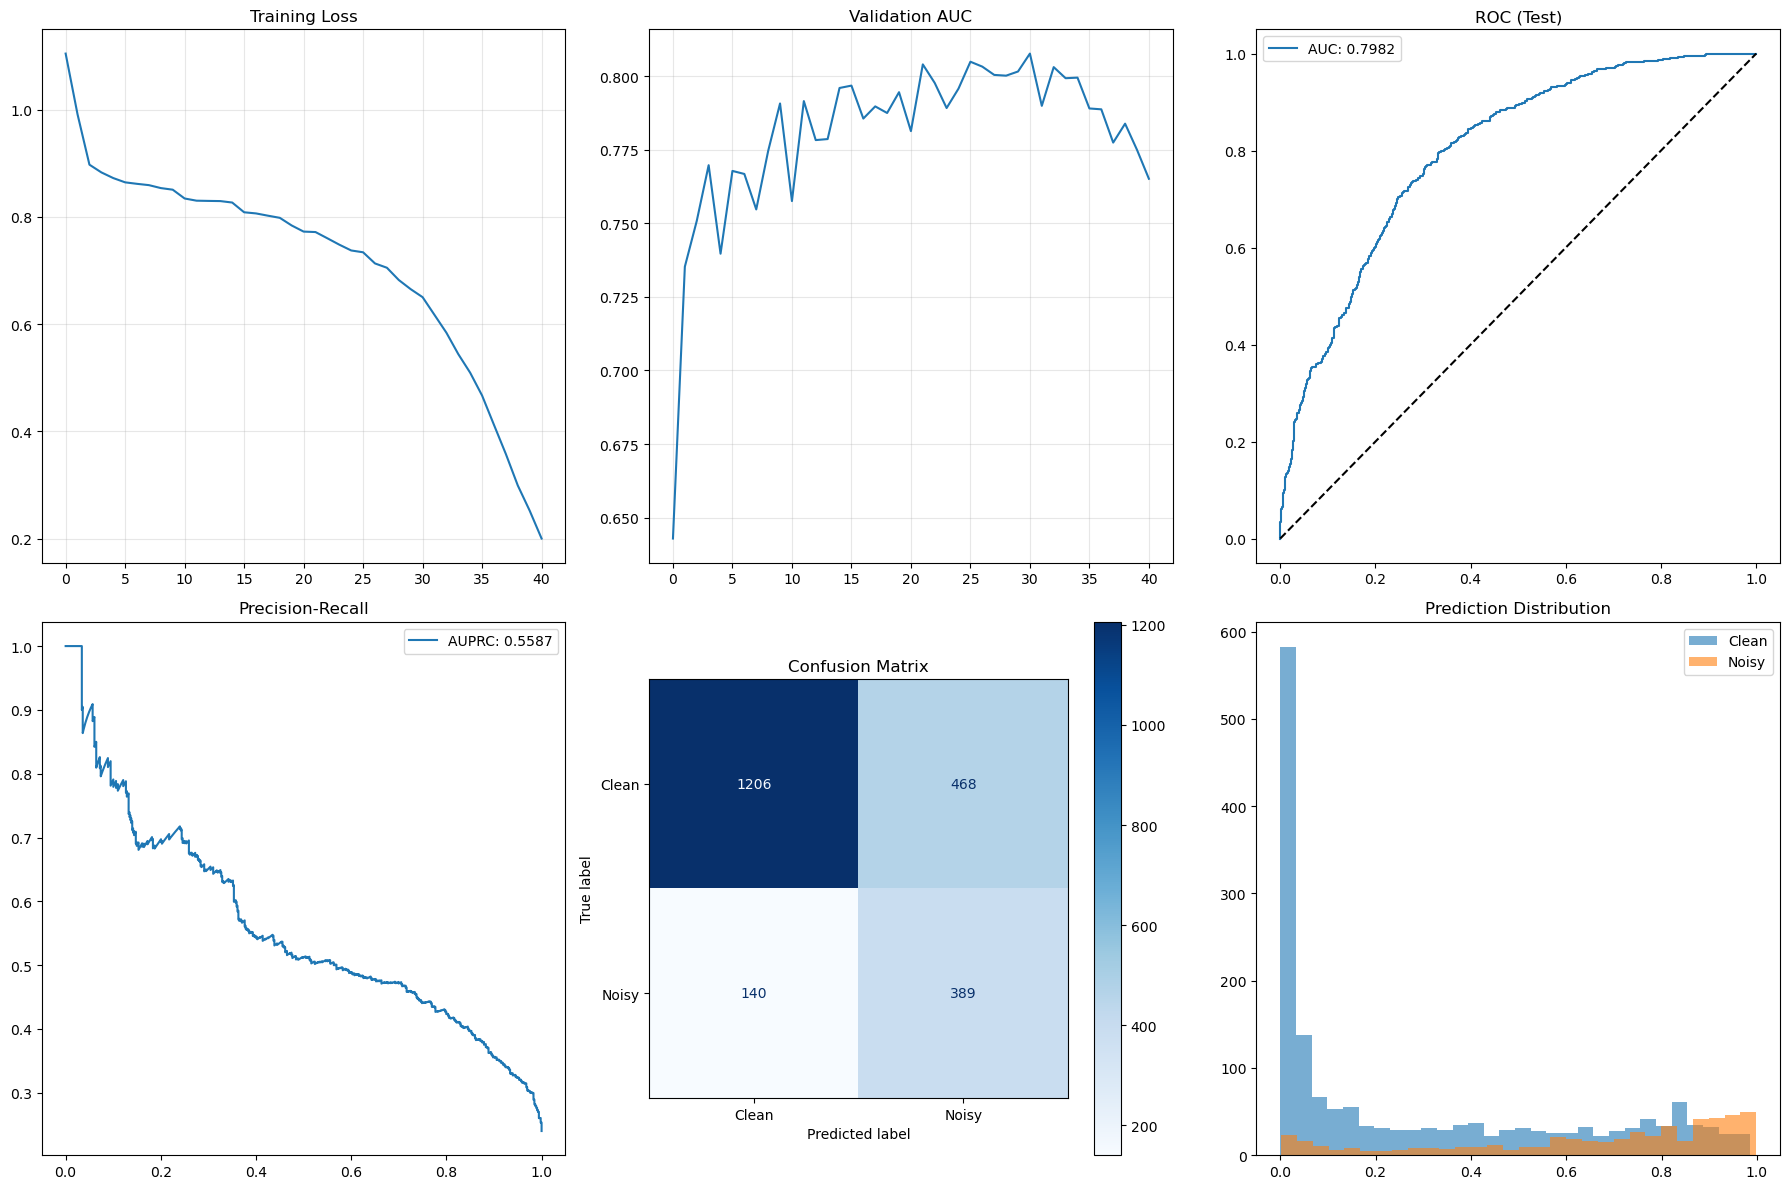

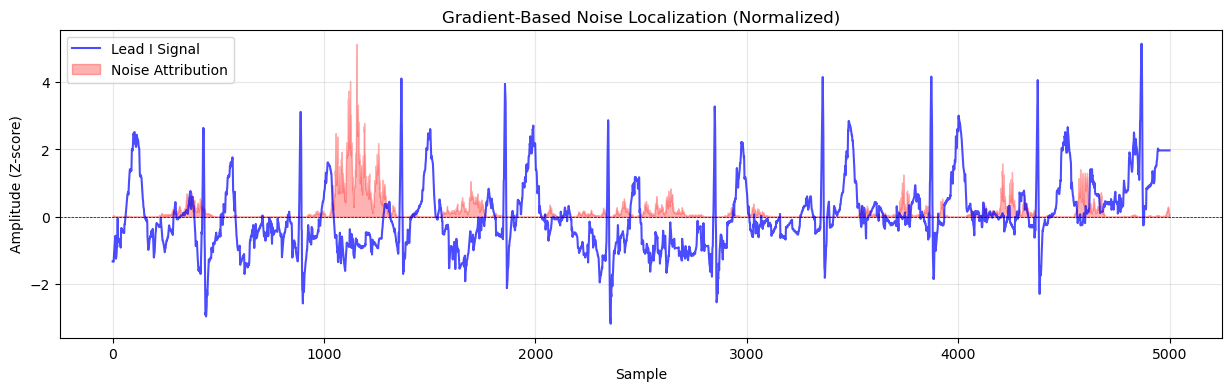

In [26]:
# =========================================================
# 6. EXECUTION
# =========================================================
if __name__ == "__main__":
    run_no_complication_pipeline()